# Homework 03: Learning Curves and Training Workflow

**Points:** 85

In this assignment, you will learn how to design, train, and evaluate neural networks by systematically exploring key design choices. Your focus will be on developing an effective **training workflow** — using learning curves and validation metrics to guide your decisions.

We'll use the **Forest Cover Type (Covertype) dataset,** which has ~581k tabular records with 54 cartographic/topographic features (elevation, aspect, slope, soil and wilderness indicators) used to predict one of seven tree cover types in Colorado’s Roosevelt National Forest. It’s a large, mildly imbalanced multi-class benchmark commonly used to compare classical ML and deep learning on tabular data.

We will start with a **baseline model** (two hidden layers of sizes 64 and 32), and gradually introduce and tune different hyperparameters. Each of the first five problems considers  different hyperparameter choices, and the last problem is your chance to use what you have learned to design your best model:

1. **Activation function** – Compare ReLU, sigmoid, and tanh to see which provides the best accuracy.
2. **Learning rate** – Explore a range of learning rates and identify which balances convergence speed and stability.
3. **Dropout** – Investigate how different dropout rates reduce overfitting and where they are most effective.
4. **L2 regularization** – Experiment with weight penalties to encourage simpler models and avoid memorization.
5. **Dropout + L2** – Combine both regularization techniques and study their interaction.
6. **Best model design** – Use all your insights to build and train your strongest model, with the option to try **learning rate scheduling** for further improvement.

In this homework, you will use **early stopping** to select the "best" model at the epoch of **minimum validation loss**, and you will report the **validation accuracy** of that selected model as the primary measure of performance. Test accuracy is reported for reference but is not used for model selection.

> **Note:** Throughout this homework, best always refers to the model selected by early stopping at the epoch of minimum validation loss. Do not report metrics from the final training epoch unless explicitly instructed.

By the end of this homework, you will not only understand how different hyperparameters affect training and generalization, but also gain hands-on practice in building a disciplined workflow for model development.

There are 10 graded problems, worth 8 points each, with 5 points for free if you complete the homework. 

In [2]:
# Useful imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import time
import os

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input,Dropout
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers.schedules import ExponentialDecay


from tensorflow.keras.datasets import fashion_mnist

# utility code

random_seed = 42

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppresses INFO and WARNING messages


In [3]:
# Utility function to plot learning curves and keep track of all results

# Call `print_results()` to see listing of all results logged so far


def plot_learning_curves(hist, title, verbose=True):
    
    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss')
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='min val loss')
    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc')
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='acc @ min val loss')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    if verbose:
        print(f"Final Training Loss:            {hist.history['loss'][-1]:.4f}")
        print(f"Final Training Accuracy:        {hist.history['accuracy'][-1]:.4f}")
        print(f"Final Validation Loss:          {hist.history['val_loss'][-1]:.4f}")
        print(f"Final Validation Accuracy:      {hist.history['val_accuracy'][-1]:.4f}")
        print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
        print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    results[title] = (val_acc_at_min_loss,min_val_epoch + 1)

results = {}

**The plotting function will record the validation accuracy for each experiment, using the plot title as key. The next function will print these out (see the last cell in the notebook).**


In order to see all results, you must give a different plot title to each experiment.

In [4]:
def print_results():
    for title, (acc, ep) in sorted(results.items(), 
                                   key=lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse=True
                                  ):
        print(f"{title:<40}\t{acc:.4f}")

### Wrapper to train, display results, and run test set

We assume multi-class classification, and allow setting various parameters for training. 

In [5]:
# Uses globals X_train,y_train,X_val,y_val

def train_and_test(model, 
                   epochs        = 500,                   # Just needs to be bigger than early stop point
                   lr_schedule   = 0.001,                 # Adam default / 10 seems to work well for this dataset
                   optimizer     = "Adam",
                   title         = "Learning Curves",
                   batch_size    = 64,                     # experiments confirmed this was optimal with other parameters at default
                   use_early_stopping = True,
                   patience      = 10,                                       
                   min_delta     = 0.0001,                 
                   callbacks     = [],                     # for extra callbacks other than early stopping
                   verbose       = 0,
                   return_history = False
                  ):

    print(f"\n{title}\n")


    if optimizer == "Adam":
        opt = Adam(learning_rate=lr_schedule) 
    else:
        opt = optimizer
    
    #Compiling the model
    model.compile(optimizer=opt, 
                  loss="sparse_categorical_crossentropy", 
                  metrics=["accuracy"]
                 )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=patience,
        min_delta=min_delta,
        restore_best_weights=True,               # this will mean that the model which produced the smallest validation loss will be returned
        verbose=verbose
    )
    

    if use_early_stopping:
        cbs=[early_stop] + callbacks
    else:
        cbs=callbacks

    # start timer
    start = time.time()
    
    # Fit the model with early stopping
    history = model.fit(X_train, y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(X_val, y_val),       # must use stratified validation set
                        callbacks=cbs,
                        verbose=verbose
                       )

    if use_early_stopping:
        best_epoch = early_stop.best_epoch
        best_acc   = history.history['val_accuracy'][best_epoch]
    else:
        best_epoch = np.argmax(history.history['val_accuracy'])
        best_acc   = history.history['val_accuracy'][best_epoch]
    
    # Plot training history
    plot_learning_curves(history, title=title)

    # Evaluate on test data
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    
    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

    print(f"\nValidation-Test Gap (accuracy): {abs(best_acc - test_accuracy):.6f}")
    
    # Record end time and print execution time
    end = time.time()
    print(f"\nExecution Time: " + format_hms(end-start))

    if return_history:
        return history

### Load the dataset and extract a stratified subset

This data set is rather large (581,012 samples) and unbalanced, but for the purposes of this homework, we use a much smaller set, and select samples so that it is balanced. 

In [6]:
# complete cell: load, balance, split into X_train/y_train/x_val/y_val/X_test/y_test, and standardize
from collections import Counter
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1) load
x, y = fetch_covtype(return_X_y=True)  # y in {1..7}
print("full dataset shape:", x.shape)

# 2) build a perfectly balanced subset across 7 classes (no replacement)
classes, counts = np.unique(y, return_counts=True)
# min_count = counts.min()  # size of rarest class                         # You can modify this parameter to increase the size of the dataset, but above
min_count = 1000                                                           # counts.min() you'll produce an unbalanced set. 


rng = np.random.default_rng(42)

idx_list = []
for c in classes:
    c_idx = np.where(y == c)[0]
    chosen = rng.choice(c_idx, size=min_count, replace=False)
    idx_list.append(chosen)

idx_bal = np.concatenate(idx_list)
rng.shuffle(idx_bal)

X_sub = x[idx_bal]
y_sub = y[idx_bal] - 1  # relabel to {0..6} for keras
print("balanced subset shape:", X_sub.shape, "class counts:", dict(Counter(y_sub)))

# 3) stratified 60/20/20 split (train/val/test)
test_size = 0.20
val_size = 0.20  # of the whole dataset

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_sub, y_sub, test_size=test_size, random_state=random_seed, stratify=y_sub
)
val_size_rel = val_size / (1.0 - test_size)  # e.g., 0.20 / 0.80 = 0.25

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_size_rel, random_state=random_seed, stratify=y_trainval
)

# 4) standardize using train-only stats (float32 for tensorflow friendliness)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

# 5) quick sanity checks
def show_counts(name, y_arr):
    c = Counter(y_arr)
    total = sum(c.values())
    print(f"{name}: total={total}, per-class={dict(c)}")

print("shapes:", "X_train", X_train.shape, "X_val", X_val.shape, "X_test", X_test.shape)
show_counts("train", y_train)
show_counts("val  ", y_val)
show_counts("test ", y_test)

# you now have: X_train, y_train, X_val, y_val, X_test, y_test

# Looks like integer encoded multi-class, let's check and define the global n_classes

labels = np.unique(y_train)

n_classes = len(labels)

print("class labels:",labels)


full dataset shape: (581012, 54)
balanced subset shape: (7000, 54) class counts: {np.int32(2): 1000, np.int32(0): 1000, np.int32(4): 1000, np.int32(5): 1000, np.int32(1): 1000, np.int32(3): 1000, np.int32(6): 1000}
shapes: X_train (4200, 54) X_val (1400, 54) X_test (1400, 54)
train: total=4200, per-class={np.int32(2): 600, np.int32(1): 600, np.int32(0): 600, np.int32(3): 600, np.int32(5): 600, np.int32(4): 600, np.int32(6): 600}
val  : total=1400, per-class={np.int32(1): 200, np.int32(6): 200, np.int32(5): 200, np.int32(4): 200, np.int32(3): 200, np.int32(2): 200, np.int32(0): 200}
test : total=1400, per-class={np.int32(0): 200, np.int32(6): 200, np.int32(2): 200, np.int32(3): 200, np.int32(4): 200, np.int32(5): 200, np.int32(1): 200}
class labels: [0 1 2 3 4 5 6]


## Prelude: Defining a model builder

In order to facilitate our experimentation, we'll write a function which builds models according to specifications:

- How many layers
- How wide each layer is
- How much dropout in each layer
- How much L2 Regularization in each layer

This is a fairly standard practice in ML, since the structure of simple models is fairly predictable and can be specified by a few hyperparameters. 

In [7]:
# This function will build a multi-class classifier with dropout and L2 regularization.
# You must specify the number of input features, the number of classes, and a list of layer hyperparameters
# in the form  [ ...., (width, activation function, L2 lambda, dropout rate), .... ]

# Note that when adding dropout, this appears as a separate layer, but it has no parameters to be trained. 

def build_model(n_inputs,layer_list,n_classes):
    layers = [ Input(shape=(n_inputs,)) ]
    for (width,act,l2_lambda,dropout_rate) in layer_list:
        layers.append( Dense(width, activation=act, kernel_regularizer=regularizers.l2(l2_lambda)) )
        if dropout_rate > 0:
            layers.append( Dropout(dropout_rate) )
    layers.append( Dense(n_classes, activation='softmax') )
    return models.Sequential( layers )


**Example: To build the following model:**

In [8]:
model = models.Sequential(
   [
    Input(shape=(X_train.shape[1],)),                              
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.0)),              # 0.0 means no regularization applied; no dropout, so no Dropout layer necessary
    Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.3),
    Dense(n_classes, activation='softmax')
   ]
)

model.summary()

2026-02-07 16:15:56.076398: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

**We call `build_model` as shown here:**

In [9]:
build_model(X_train.shape[1], [ (64,'relu',0.0,0.0), (32,'relu',0.001,0.3)], n_classes).summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

-------------------



### Baseline Model Architecture

**Problems 1–5 will use the following baseline model structure,** implemented with the provided `build_model` function and trained using `train_and_test`:

```
input → 64 → 32 → output
```

* Two hidden layers of widths 64 and 32.
* Activation function, dropout rate, and L2 regularization term (λ) will vary as specified in each problem.
* **Early stopping** is always applied to select the model at the epoch of **minimum validation loss**.
* We will report the **validation accuracy** of the selected model as the primary metric.


### Problem One: Which Activation Function?

In this problem, you will train the **baseline neural network** and investigate which activation function produces the best performance. The model you create will be the one saved by **early stopping** — that is, the epoch where validation loss is minimized.

**Steps to follow:**

* Use the provided functions `train_and_test` and `build_model` to create a model named **`model_baseline`**.
* Train and evaluate this model using each of the following activation functions in the hidden layers:

  * `relu`
  * `sigmoid`
  * `tanh`
* Identify which activation function produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.



Baseline (64→32), activation=relu



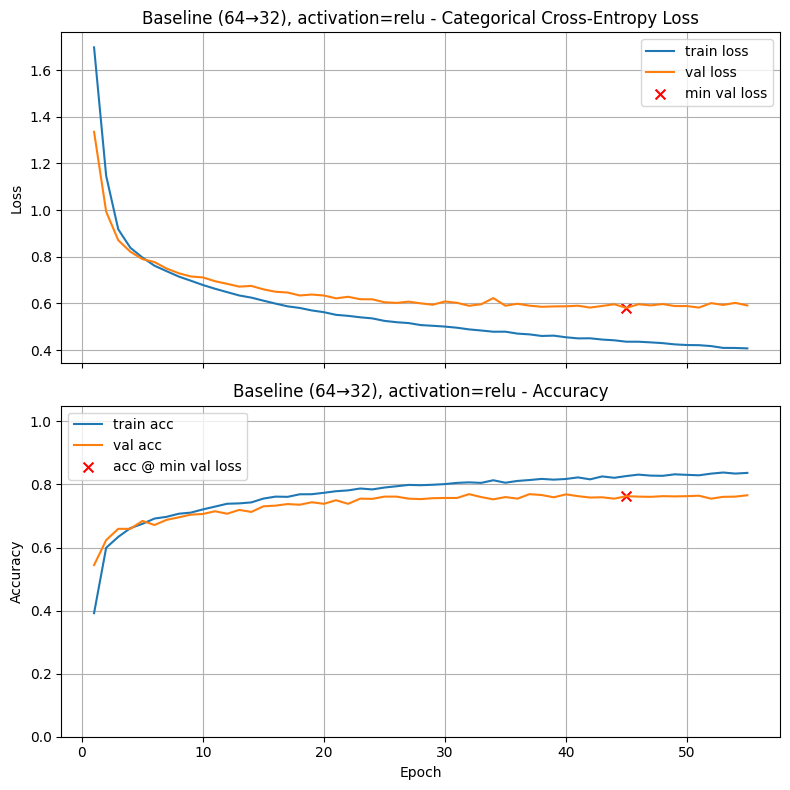

Final Training Loss:            0.4076
Final Training Accuracy:        0.8367
Final Validation Loss:          0.5915
Final Validation Accuracy:      0.7657
Minimum Validation Loss:        0.5810 (Epoch 45)
Validation Accuracy @ Min Loss: 0.7629

Test Loss: 0.6035
Test Accuracy: 0.7507

Validation-Test Gap (accuracy): 0.012143

Execution Time: 00:00:10


In [10]:
# Your code here. Add as many cells as you need. 
W1, W2 = 64, 32
l2_lambda = 0.0
dropout_rate = 0.0

results = {}

n_inputs  = X_train.shape[1]
n_classes = len(np.unique(y_train))

## ReLU function
act = "relu"
layer_list = [(W1, act, l2_lambda, dropout_rate),
              (W2, act, l2_lambda, dropout_rate)]

model_baseline = build_model(n_inputs, layer_list, n_classes)
hist_relu = train_and_test(model_baseline, title="Baseline (64→32), activation=relu", return_history=True)

best_epoch_relu = int(np.argmin(hist_relu.history["val_loss"]))
best_val_acc_relu = float(hist_relu.history["val_accuracy"][best_epoch_relu])
results["relu"] = {"best_epoch": best_epoch_relu + 1, "val_acc": best_val_acc_relu}



Baseline (64→32), activation=sigmoid



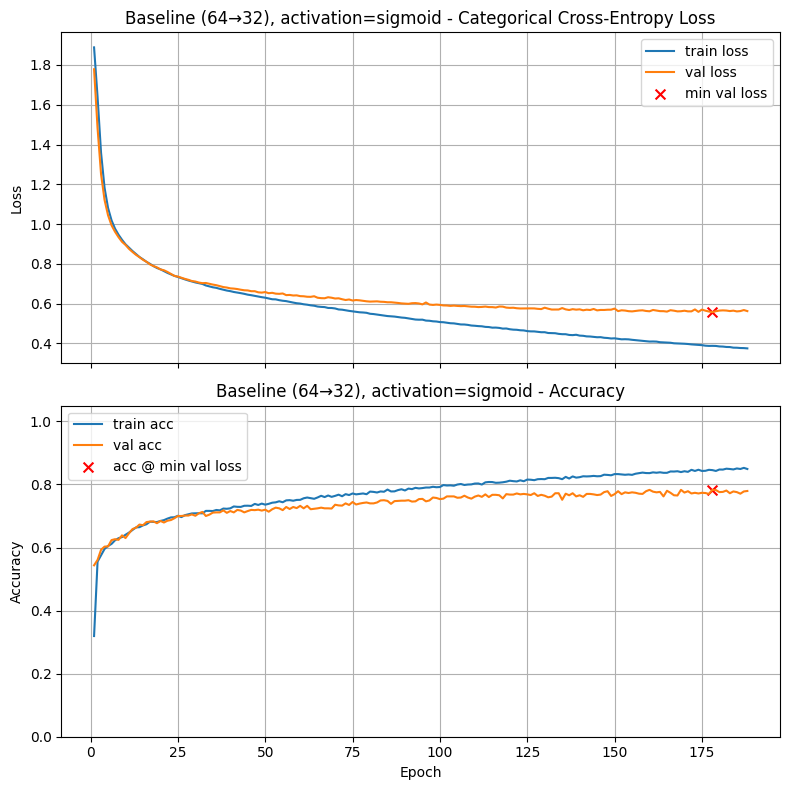

Final Training Loss:            0.3744
Final Training Accuracy:        0.8490
Final Validation Loss:          0.5619
Final Validation Accuracy:      0.7793
Minimum Validation Loss:        0.5566 (Epoch 178)
Validation Accuracy @ Min Loss: 0.7829

Test Loss: 0.5644
Test Accuracy: 0.7529

Validation-Test Gap (accuracy): 0.030000

Execution Time: 00:00:28


In [11]:
## Sigmoid Function
act = "sigmoid"
layer_list = [(W1, act, l2_lambda, dropout_rate),
              (W2, act, l2_lambda, dropout_rate)]

model_baseline = build_model(n_inputs, layer_list, n_classes)
hist_sigmoid = train_and_test(model_baseline, title="Baseline (64→32), activation=sigmoid", return_history=True)

best_epoch_sigmoid = int(np.argmin(hist_sigmoid.history["val_loss"]))
best_val_acc_sigmoid = float(hist_sigmoid.history["val_accuracy"][best_epoch_sigmoid])
results["sigmoid"] = {"best_epoch": best_epoch_sigmoid + 1, "val_acc": best_val_acc_sigmoid}


Baseline (64→32), activation=tanh



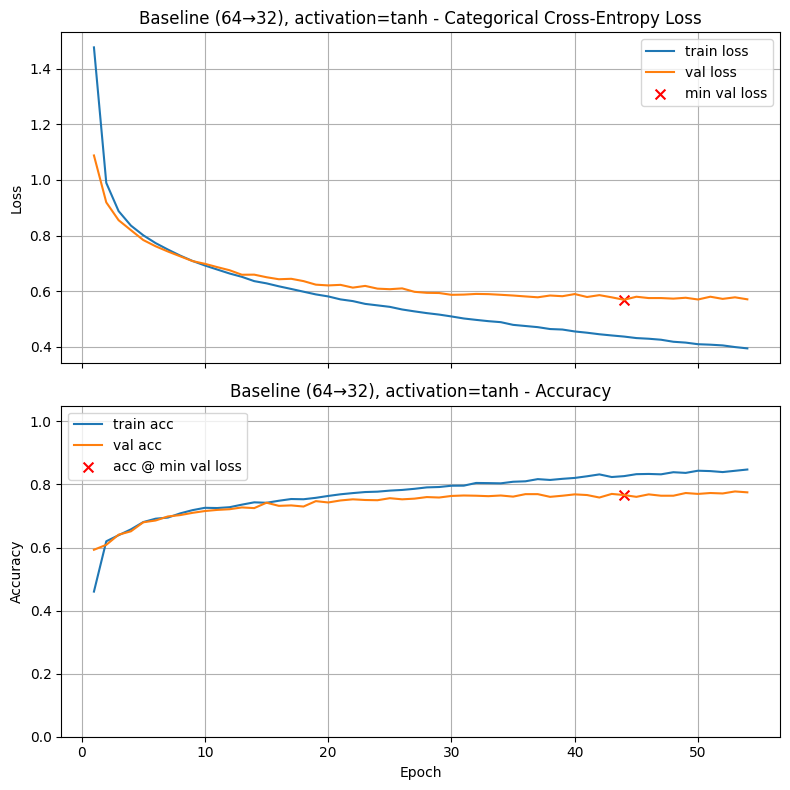

Final Training Loss:            0.3941
Final Training Accuracy:        0.8474
Final Validation Loss:          0.5706
Final Validation Accuracy:      0.7750
Minimum Validation Loss:        0.5690 (Epoch 44)
Validation Accuracy @ Min Loss: 0.7664

Test Loss: 0.5731
Test Accuracy: 0.7536

Validation-Test Gap (accuracy): 0.012857

Execution Time: 00:00:09


In [12]:
## Tanh Function
act = "tanh"
layer_list = [(W1, act, l2_lambda, dropout_rate),
              (W2, act, l2_lambda, dropout_rate)]

model_baseline = build_model(n_inputs, layer_list, n_classes)
hist_tanh = train_and_test(model_baseline, title="Baseline (64→32), activation=tanh", return_history=True)

best_epoch_tanh = int(np.argmin(hist_tanh.history["val_loss"]))
best_val_acc_tanh = float(hist_tanh.history["val_accuracy"][best_epoch_tanh])
results["tanh"] = {"best_epoch": best_epoch_tanh + 1, "val_acc": best_val_acc_tanh}

In [13]:
print("\nValidation accuracy at the epoch of MIN validation loss:")
for k in ["relu", "sigmoid", "tanh"]:
    print(f"{k:7s} -> best_epoch={results[k]['best_epoch']:>3d}, val_acc={results[k]['val_acc']:.4f}")

best_act = max(
    results.keys(),
    key=lambda a: results[a]["val_acc"] if isinstance(results[a], dict) else results[a][1]
)
print("\nBest activation:", best_act)


Validation accuracy at the epoch of MIN validation loss:
relu    -> best_epoch= 45, val_acc=0.7629
sigmoid -> best_epoch=178, val_acc=0.7829
tanh    -> best_epoch= 44, val_acc=0.7664

Best activation: Baseline (64→32), activation=sigmoid


### Graded Questions

In [14]:
# Set a1a to the activation function which provided the best validation accuracy at the epoch of minimum validation loss

a1a = 1             # Replace with integer 0 (relu), 1 (sigmoid), or 2 (tanh)

In [15]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1a = {a1a}') 


a1a = 1


In [16]:
# Set a1b to the validation accuracy found by this best activation function

a1b = 0.7736             # Replace 0.0 with your answer

In [17]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1b = {a1b:.4f}') 

a1b = 0.7736


### Problem Two: Finding the Right Learning Rate

In this problem, you will continue working with the **baseline model** and determine which learning rate produces the best performance. As before, the model you evaluate should be the one saved by **early stopping** — the epoch where validation loss is minimized.

**Steps to follow:**

* Build and train the **baseline model** using the **activation function identified in Problem One**.

* Train and evaluate this model using each of the following learning rates:

  ```
      [1e-3, 5e-4, 1e-4, 5e-5, 1e-5]
  ```

* Identify which learning rate produces the **best validation accuracy** at the epoch of **minimum validation loss**, within a maximum of **500 epochs**.

* Answer the graded questions.


**Note: Smaller learning rates will generally take more epochs to reach the optimal point, so some of these will not engage early stopping, but run the full 500 epochs.**


In [18]:
# Your code here. Add as many cells as you need. 
best_activation = "sigmoid"

n_inputs = X_train.shape[1]
n_classes = len(np.unique(y_train))

W1, W2 = 64, 32
l2_lambda = 0.0
dropout_rate = 0.0

learning_rates = [1e-3, 5e-4, 1e-4, 5e-5, 1e-5]
results_lr = {}

def best_val_acc_from_history(hist):
    """Return (best_epoch_index, best_val_loss, val_acc_at_best_val_loss)"""
    best_idx = int(np.argmin(hist.history["val_loss"]))
    best_vloss = float(hist.history["val_loss"][best_idx])
    best_vacc  = float(hist.history["val_accuracy"][best_idx])
    return best_idx, best_vloss, best_vacc


Baseline (64→32), act=sigmoid, lr=0.001



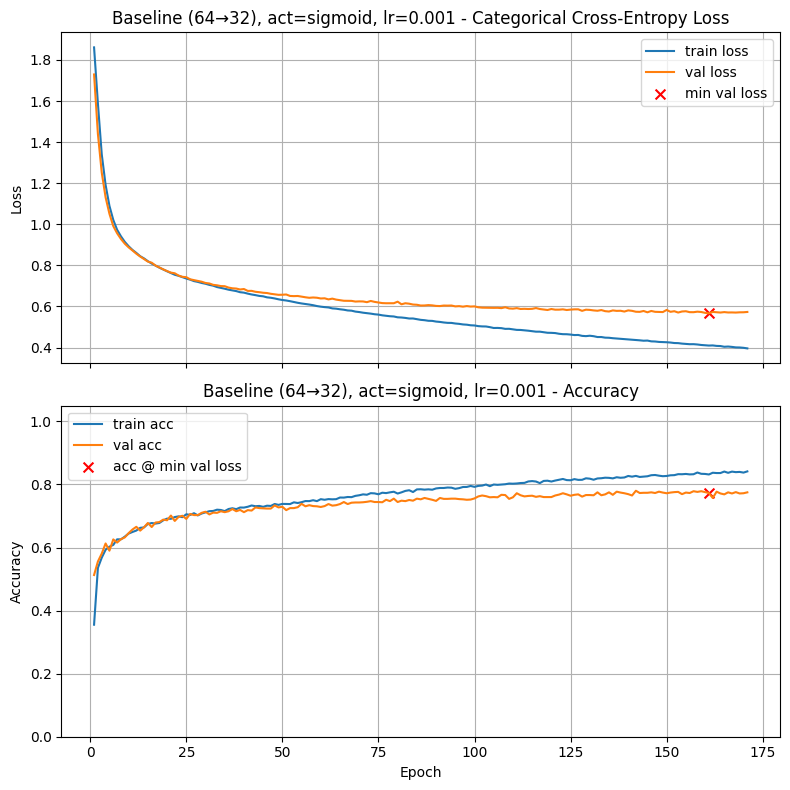

Final Training Loss:            0.3961
Final Training Accuracy:        0.8414
Final Validation Loss:          0.5734
Final Validation Accuracy:      0.7750
Minimum Validation Loss:        0.5666 (Epoch 161)
Validation Accuracy @ Min Loss: 0.7729

Test Loss: 0.5790
Test Accuracy: 0.7679

Validation-Test Gap (accuracy): 0.005000

Execution Time: 00:00:26


In [19]:
## 1e-3
lr = 1e-3
layer_list = [(W1, best_activation, l2_lambda, dropout_rate),
              (W2, best_activation, l2_lambda, dropout_rate)]
model = build_model(n_inputs, layer_list, n_classes)
hist = train_and_test(model, epochs=500, lr_schedule=lr,
                      title=f"Baseline (64→32), act={best_activation}, lr={lr}",
                      return_history=True)
idx, vloss, vacc = best_val_acc_from_history(hist)
results_lr[lr] = {"best_epoch": idx + 1, "val_loss": vloss, "val_acc": vacc}



Baseline (64→32), act=sigmoid, lr=0.0005



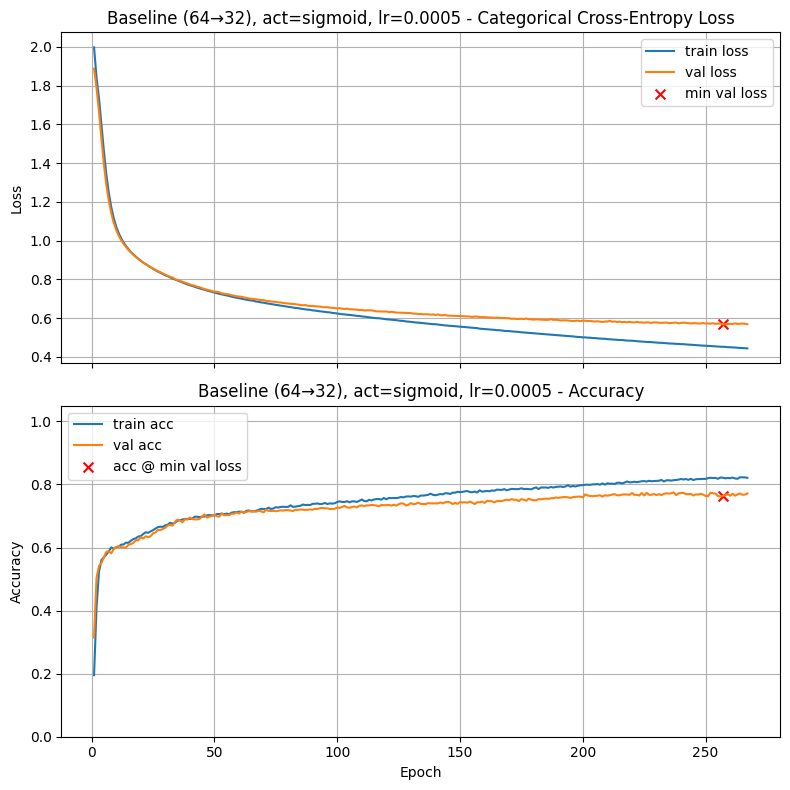

Final Training Loss:            0.4433
Final Training Accuracy:        0.8212
Final Validation Loss:          0.5683
Final Validation Accuracy:      0.7714
Minimum Validation Loss:        0.5669 (Epoch 257)
Validation Accuracy @ Min Loss: 0.7636

Test Loss: 0.5856
Test Accuracy: 0.7529

Validation-Test Gap (accuracy): 0.010714

Execution Time: 00:00:41


In [20]:
## 5e-4
lr = 5e-4
layer_list = [(W1, best_activation, l2_lambda, dropout_rate),
              (W2, best_activation, l2_lambda, dropout_rate)]
model = build_model(n_inputs, layer_list, n_classes)
hist = train_and_test(model, epochs=500, lr_schedule=lr,
                      title=f"Baseline (64→32), act={best_activation}, lr={lr}",
                      return_history=True)
idx, vloss, vacc = best_val_acc_from_history(hist)
results_lr[lr] = {"best_epoch": idx + 1, "val_loss": vloss, "val_acc": vacc}


Baseline (64→32), act=sigmoid, lr=0.0001



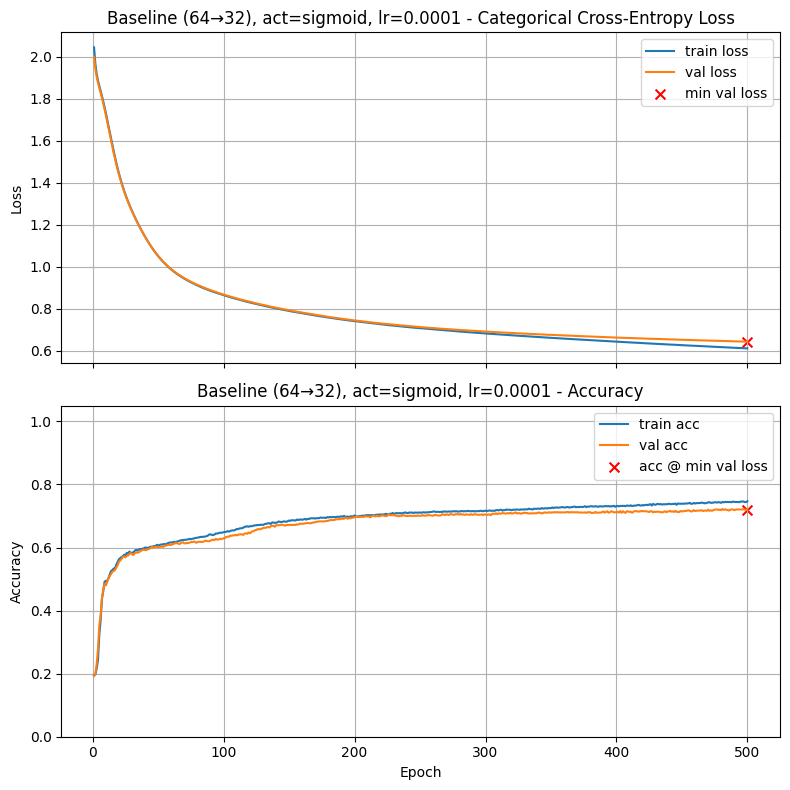

Final Training Loss:            0.6119
Final Training Accuracy:        0.7464
Final Validation Loss:          0.6438
Final Validation Accuracy:      0.7193
Minimum Validation Loss:        0.6438 (Epoch 500)
Validation Accuracy @ Min Loss: 0.7193

Test Loss: 0.6674
Test Accuracy: 0.7193

Validation-Test Gap (accuracy): 0.000000

Execution Time: 00:01:14


In [21]:
## 1e-4
lr = 1e-4
layer_list = [(W1, best_activation, l2_lambda, dropout_rate),
              (W2, best_activation, l2_lambda, dropout_rate)]
model = build_model(n_inputs, layer_list, n_classes)
hist = train_and_test(model, epochs=500, lr_schedule=lr,
                      title=f"Baseline (64→32), act={best_activation}, lr={lr}",
                      return_history=True)
idx, vloss, vacc = best_val_acc_from_history(hist)
results_lr[lr] = {"best_epoch": idx + 1, "val_loss": vloss, "val_acc": vacc}



Baseline (64→32), act=sigmoid, lr=5e-05



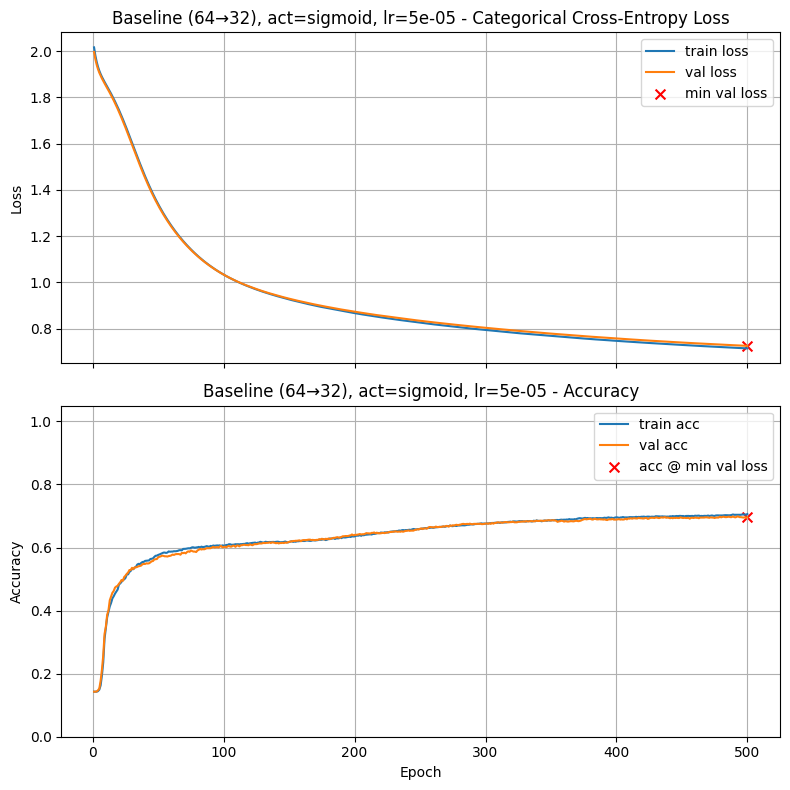

Final Training Loss:            0.7143
Final Training Accuracy:        0.7062
Final Validation Loss:          0.7252
Final Validation Accuracy:      0.6957
Minimum Validation Loss:        0.7252 (Epoch 500)
Validation Accuracy @ Min Loss: 0.6957

Test Loss: 0.7430
Test Accuracy: 0.6971

Validation-Test Gap (accuracy): 0.001429

Execution Time: 00:01:14


In [22]:
## 5e-5
lr = 5e-5
layer_list = [(W1, best_activation, l2_lambda, dropout_rate),
              (W2, best_activation, l2_lambda, dropout_rate)]
model = build_model(n_inputs, layer_list, n_classes)
hist = train_and_test(model, epochs=500, lr_schedule=lr,
                      title=f"Baseline (64→32), act={best_activation}, lr={lr}",
                      return_history=True)
idx, vloss, vacc = best_val_acc_from_history(hist)
results_lr[lr] = {"best_epoch": idx + 1, "val_loss": vloss, "val_acc": vacc}


Baseline (64→32), act=sigmoid, lr=1e-05



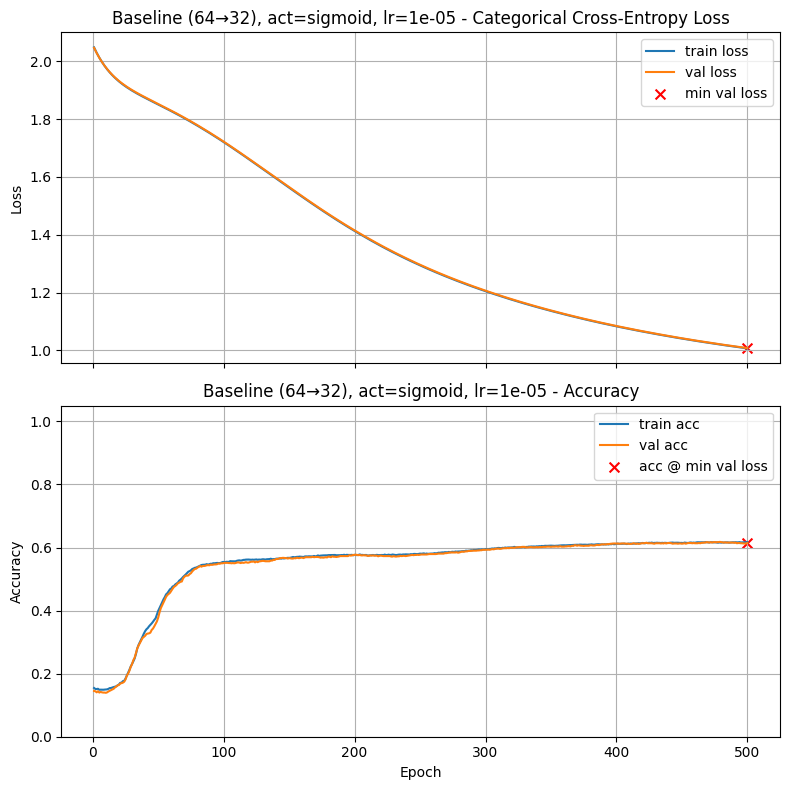

Final Training Loss:            1.0070
Final Training Accuracy:        0.6174
Final Validation Loss:          1.0079
Final Validation Accuracy:      0.6143
Minimum Validation Loss:        1.0079 (Epoch 500)
Validation Accuracy @ Min Loss: 0.6143

Test Loss: 1.0116
Test Accuracy: 0.6200

Validation-Test Gap (accuracy): 0.005714

Execution Time: 00:01:09


In [23]:
## 1e-5
lr = 1e-5
layer_list = [(W1, best_activation, l2_lambda, dropout_rate),
              (W2, best_activation, l2_lambda, dropout_rate)]
model = build_model(n_inputs, layer_list, n_classes)
hist = train_and_test(model, epochs=500, lr_schedule=lr,
                      title=f"Baseline (64→32), act={best_activation}, lr={lr}",
                      return_history=True)
idx, vloss, vacc = best_val_acc_from_history(hist)
results_lr[lr] = {"best_epoch": idx + 1, "val_loss": vloss, "val_acc": vacc}

In [24]:
print("\nValidation accuracy at epoch of MIN val_loss (early-stopping selected):")
for lr in learning_rates:
    r = results_lr[lr]
    print(f"lr={lr:>7g} | best_epoch={r['best_epoch']:>3d} | val_loss={r['val_loss']:.4f} | val_acc={r['val_acc']:.4f}")

best_lr = max(results_lr.keys(), key=lambda x: results_lr[x]["val_acc"])
print("\nBest learning rate:", best_lr)


Validation accuracy at epoch of MIN val_loss (early-stopping selected):
lr=  0.001 | best_epoch=161 | val_loss=0.5666 | val_acc=0.7729
lr= 0.0005 | best_epoch=257 | val_loss=0.5669 | val_acc=0.7636
lr= 0.0001 | best_epoch=500 | val_loss=0.6438 | val_acc=0.7193
lr=  5e-05 | best_epoch=500 | val_loss=0.7252 | val_acc=0.6957
lr=  1e-05 | best_epoch=500 | val_loss=1.0079 | val_acc=0.6143

Best learning rate: 0.001


#### Graded Questions

In [25]:
# Set a2a to the learning rate which provided the best validation accuracy at the epoch of minimum validation loss

a2a = 0.0005           # Replace 0.0 with your answer

In [26]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2a = {a2a:.6f}') 

a2a = 0.000500


In [27]:
# Set a2b to the validation accuracy found by this best learning rate

a2b = 0.7736             # Replace 0.0 with your answer

In [28]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2b = {a2b:.4f}') 

a2b = 0.7736


### Problem Three: Dropout

In this problem, you will explore how **dropout** can help prevent overfitting in neural networks. There are no absolute rules, but some useful heuristics are:

* Dropout typically works best in **later dense layers** (e.g., the second hidden layer of width 32) in the range **0.3–0.5**.
* If applied to **earlier layers** (e.g., the first hidden layer), dropout should be smaller, typically **0.0–0.2** (where 0.0 means no dropout).

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**.
* Investigate dropout in the ranges suggested, using increments of **0.1**.
* Identify which dropout configuration produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.



Dropout search: act=sigmoid, lr=0.0005, d1=0.0, d2=0.0



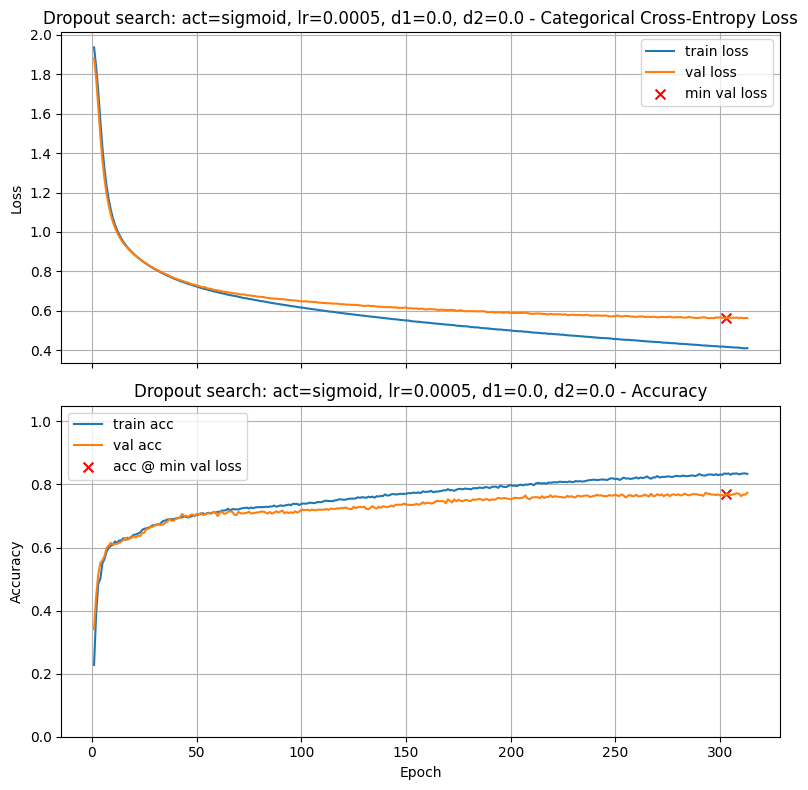

Final Training Loss:            0.4108
Final Training Accuracy:        0.8336
Final Validation Loss:          0.5630
Final Validation Accuracy:      0.7736
Minimum Validation Loss:        0.5613 (Epoch 303)
Validation Accuracy @ Min Loss: 0.7686

Test Loss: 0.5693
Test Accuracy: 0.7650

Validation-Test Gap (accuracy): 0.003571

Execution Time: 00:00:44

Dropout search: act=sigmoid, lr=0.0005, d1=0.0, d2=0.1



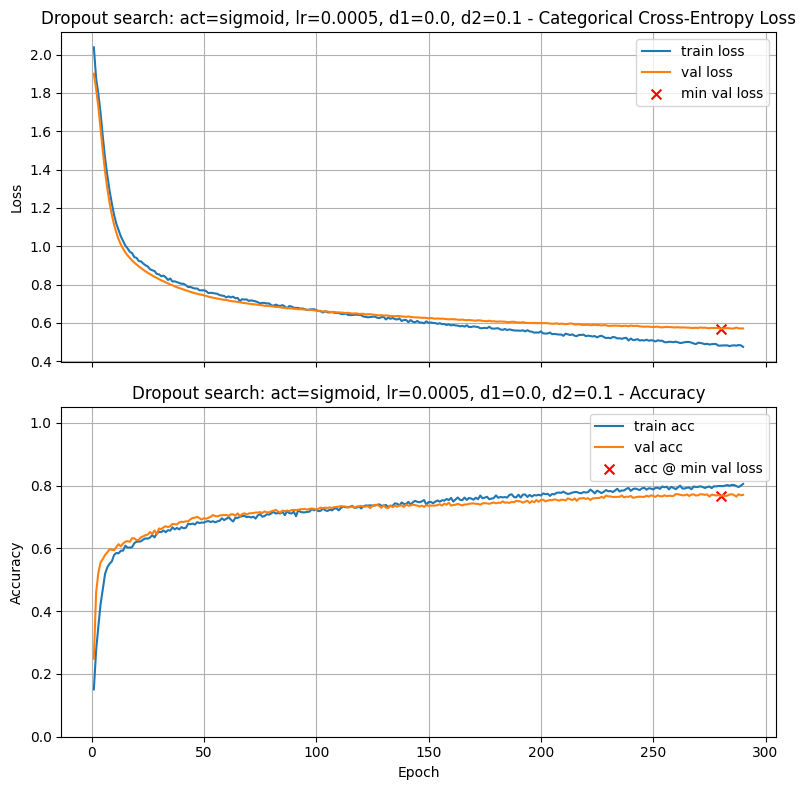

Final Training Loss:            0.4751
Final Training Accuracy:        0.8055
Final Validation Loss:          0.5712
Final Validation Accuracy:      0.7707
Minimum Validation Loss:        0.5702 (Epoch 280)
Validation Accuracy @ Min Loss: 0.7671

Test Loss: 0.5951
Test Accuracy: 0.7607

Validation-Test Gap (accuracy): 0.006429

Execution Time: 00:00:42

Dropout search: act=sigmoid, lr=0.0005, d1=0.0, d2=0.2



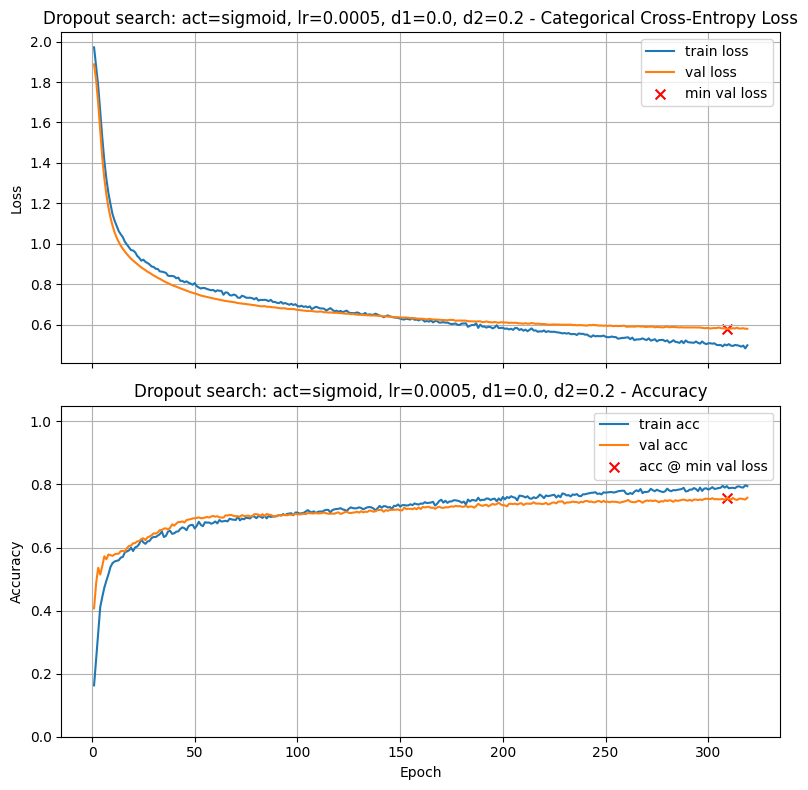

Final Training Loss:            0.4972
Final Training Accuracy:        0.7948
Final Validation Loss:          0.5786
Final Validation Accuracy:      0.7579
Minimum Validation Loss:        0.5785 (Epoch 309)
Validation Accuracy @ Min Loss: 0.7586

Test Loss: 0.5967
Test Accuracy: 0.7586

Validation-Test Gap (accuracy): 0.000000

Execution Time: 00:00:46

Dropout search: act=sigmoid, lr=0.0005, d1=0.0, d2=0.3



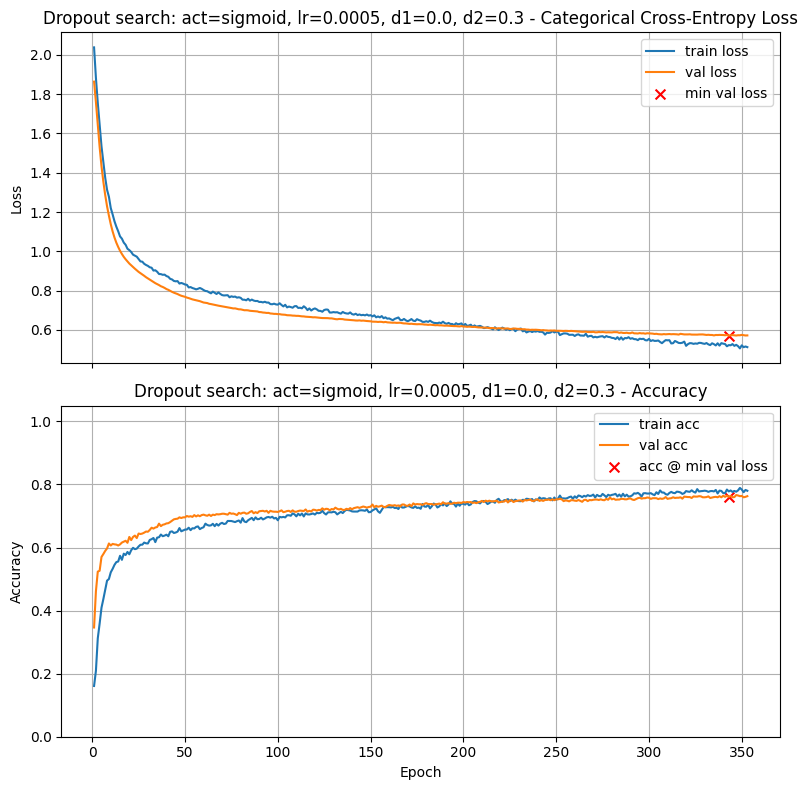

Final Training Loss:            0.5128
Final Training Accuracy:        0.7800
Final Validation Loss:          0.5724
Final Validation Accuracy:      0.7629
Minimum Validation Loss:        0.5714 (Epoch 343)
Validation Accuracy @ Min Loss: 0.7607

Test Loss: 0.6038
Test Accuracy: 0.7529

Validation-Test Gap (accuracy): 0.007857

Execution Time: 00:00:52

Dropout search: act=sigmoid, lr=0.0005, d1=0.0, d2=0.4



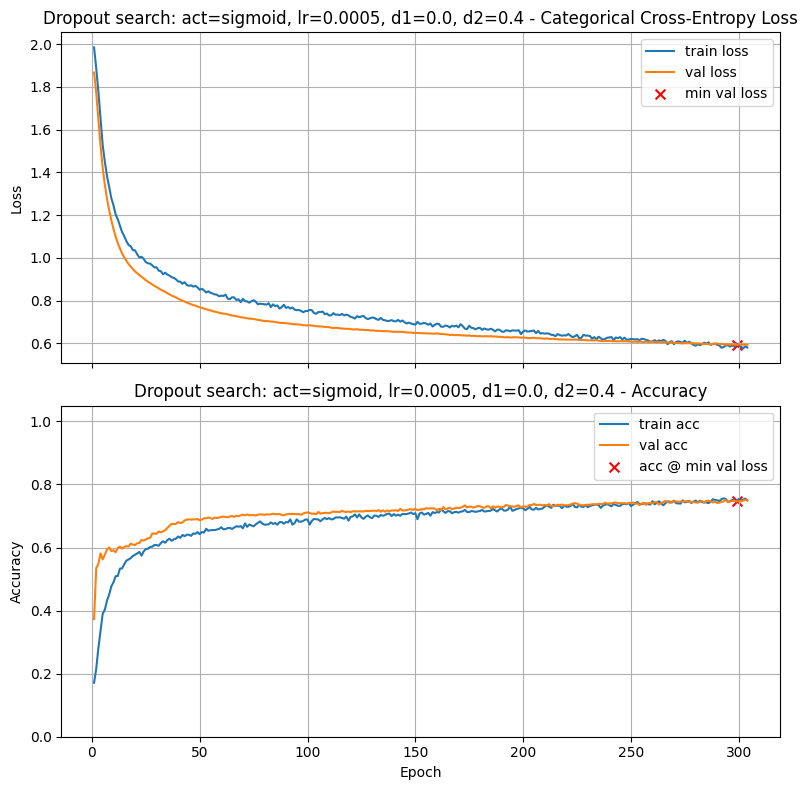

Final Training Loss:            0.5806
Final Training Accuracy:        0.7500
Final Validation Loss:          0.5935
Final Validation Accuracy:      0.7493
Minimum Validation Loss:        0.5933 (Epoch 299)
Validation Accuracy @ Min Loss: 0.7471

Test Loss: 0.6129
Test Accuracy: 0.7329

Validation-Test Gap (accuracy): 0.017857

Execution Time: 00:00:44

Dropout search: act=sigmoid, lr=0.0005, d1=0.0, d2=0.5



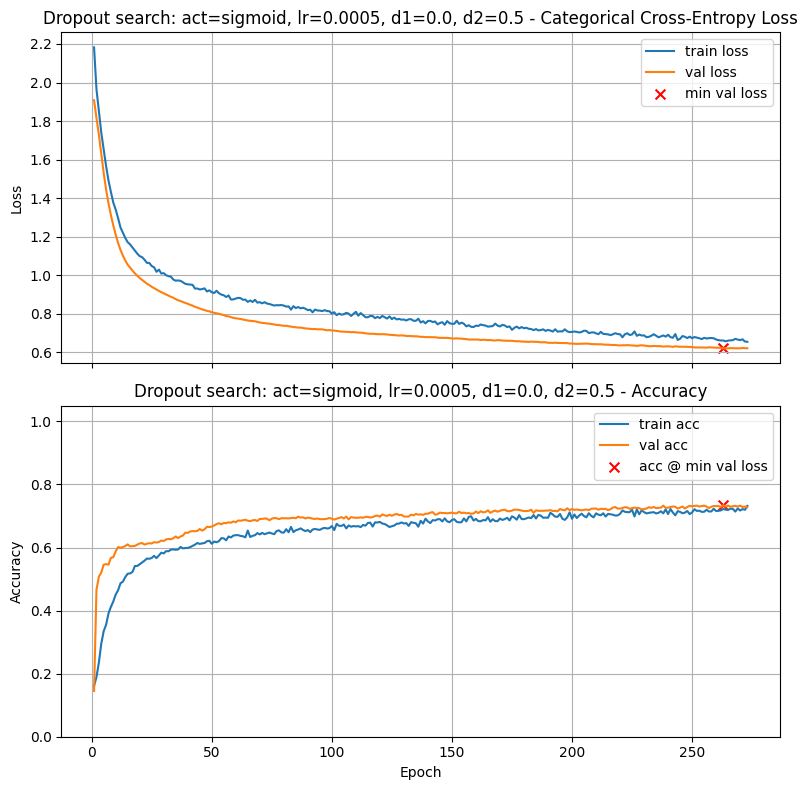

Final Training Loss:            0.6533
Final Training Accuracy:        0.7321
Final Validation Loss:          0.6200
Final Validation Accuracy:      0.7279
Minimum Validation Loss:        0.6193 (Epoch 263)
Validation Accuracy @ Min Loss: 0.7343

Test Loss: 0.6419
Test Accuracy: 0.7129

Validation-Test Gap (accuracy): 0.021429

Execution Time: 00:00:40

Dropout search: act=sigmoid, lr=0.0005, d1=0.1, d2=0.0



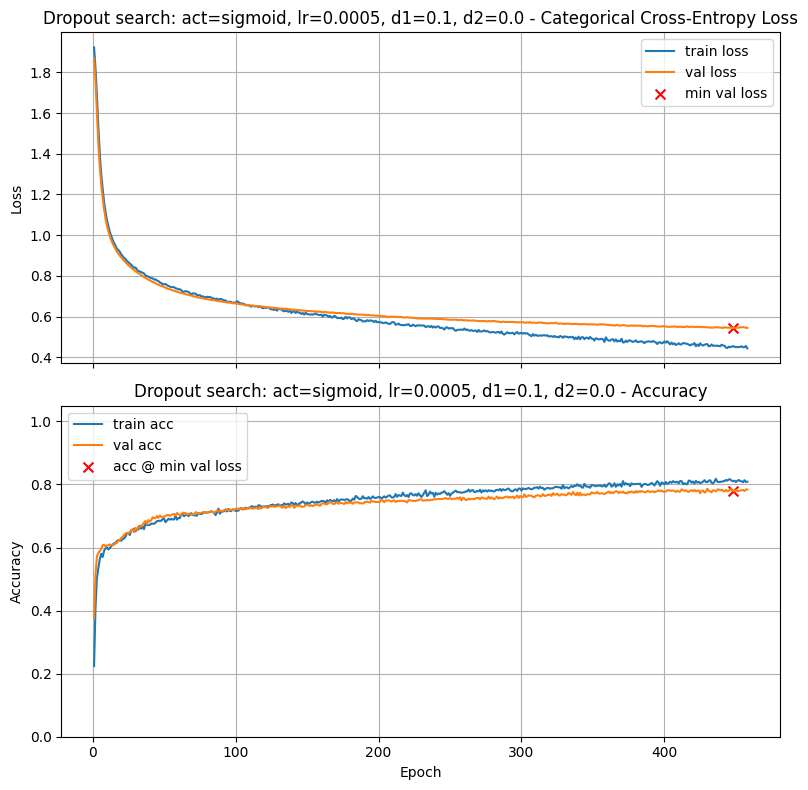

Final Training Loss:            0.4435
Final Training Accuracy:        0.8088
Final Validation Loss:          0.5439
Final Validation Accuracy:      0.7836
Minimum Validation Loss:        0.5433 (Epoch 448)
Validation Accuracy @ Min Loss: 0.7807

Test Loss: 0.5572
Test Accuracy: 0.7750

Validation-Test Gap (accuracy): 0.005714

Execution Time: 00:01:08

Dropout search: act=sigmoid, lr=0.0005, d1=0.1, d2=0.1



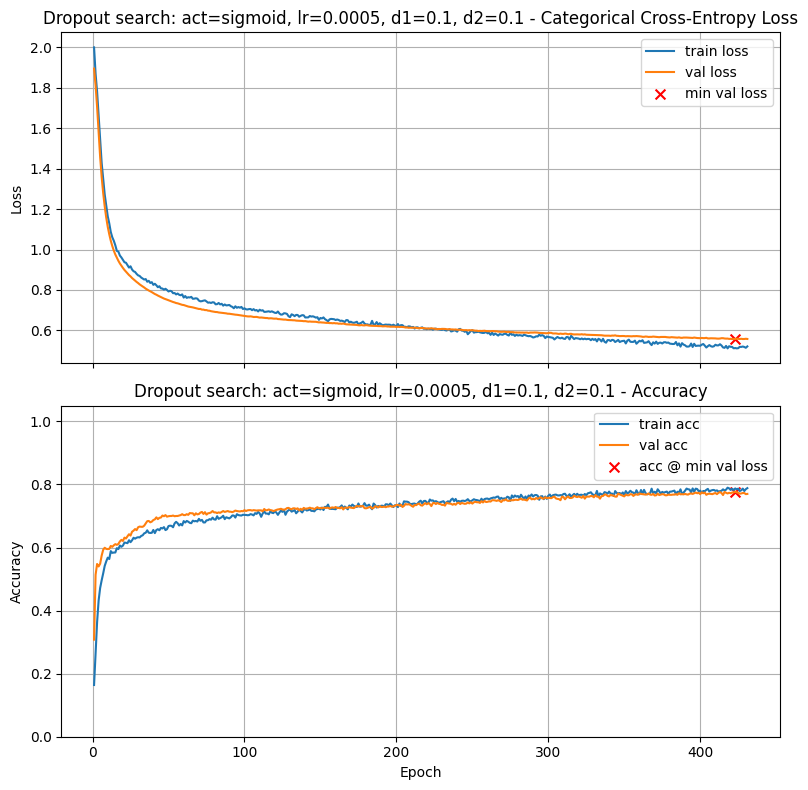

Final Training Loss:            0.5211
Final Training Accuracy:        0.7883
Final Validation Loss:          0.5579
Final Validation Accuracy:      0.7700
Minimum Validation Loss:        0.5574 (Epoch 423)
Validation Accuracy @ Min Loss: 0.7771

Test Loss: 0.5769
Test Accuracy: 0.7593

Validation-Test Gap (accuracy): 0.015000

Execution Time: 00:01:03

Dropout search: act=sigmoid, lr=0.0005, d1=0.1, d2=0.2



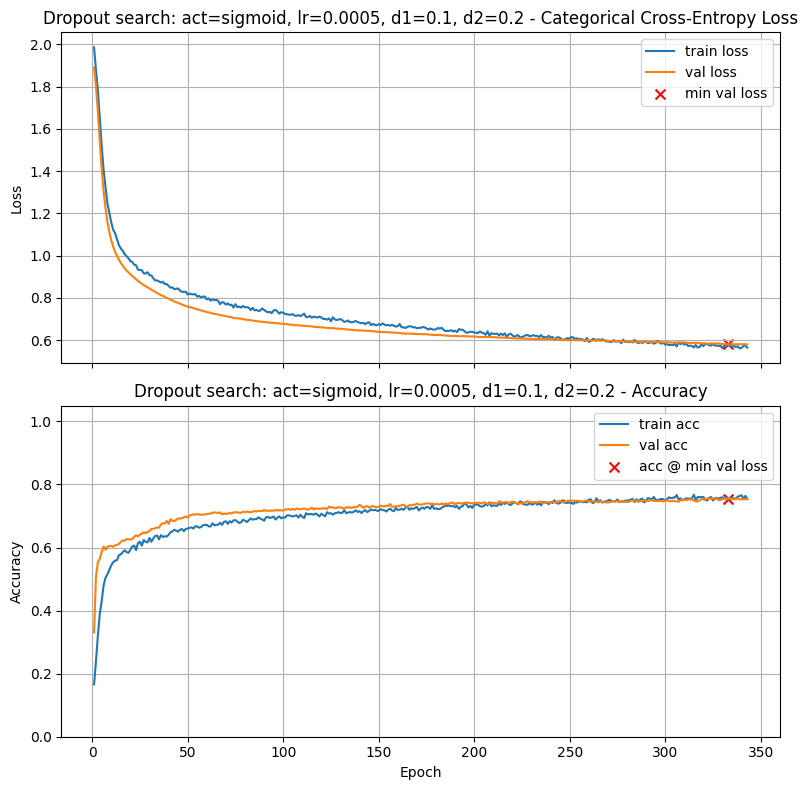

Final Training Loss:            0.5642
Final Training Accuracy:        0.7543
Final Validation Loss:          0.5800
Final Validation Accuracy:      0.7536
Minimum Validation Loss:        0.5798 (Epoch 333)
Validation Accuracy @ Min Loss: 0.7550

Test Loss: 0.5895
Test Accuracy: 0.7557

Validation-Test Gap (accuracy): 0.000714

Execution Time: 00:00:52

Dropout search: act=sigmoid, lr=0.0005, d1=0.1, d2=0.3



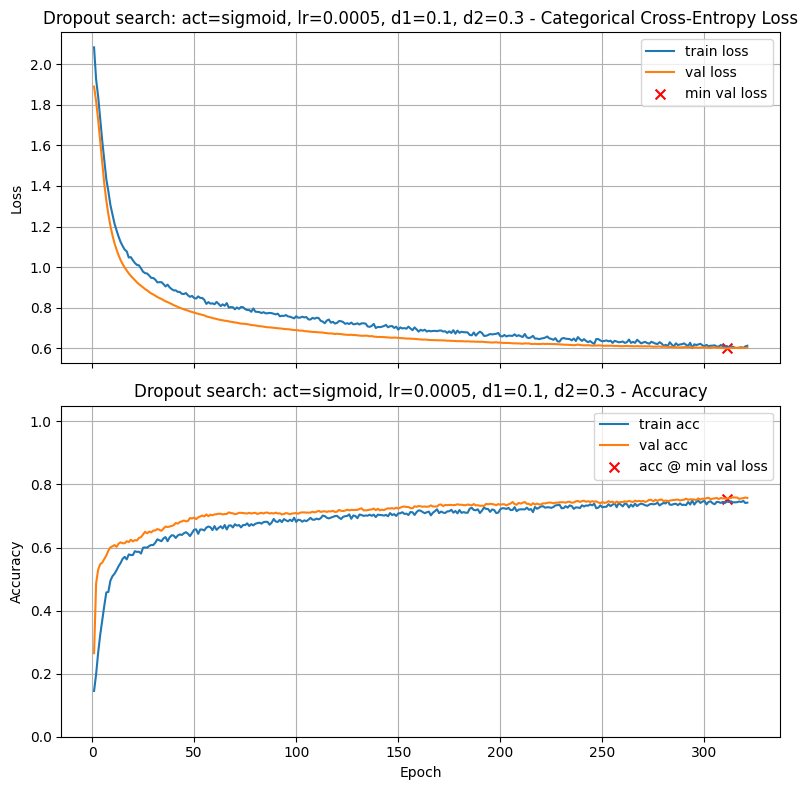

Final Training Loss:            0.6116
Final Training Accuracy:        0.7424
Final Validation Loss:          0.6008
Final Validation Accuracy:      0.7571
Minimum Validation Loss:        0.5986 (Epoch 311)
Validation Accuracy @ Min Loss: 0.7550

Test Loss: 0.6170
Test Accuracy: 0.7357

Validation-Test Gap (accuracy): 0.019286

Execution Time: 00:00:48

Dropout search: act=sigmoid, lr=0.0005, d1=0.1, d2=0.4



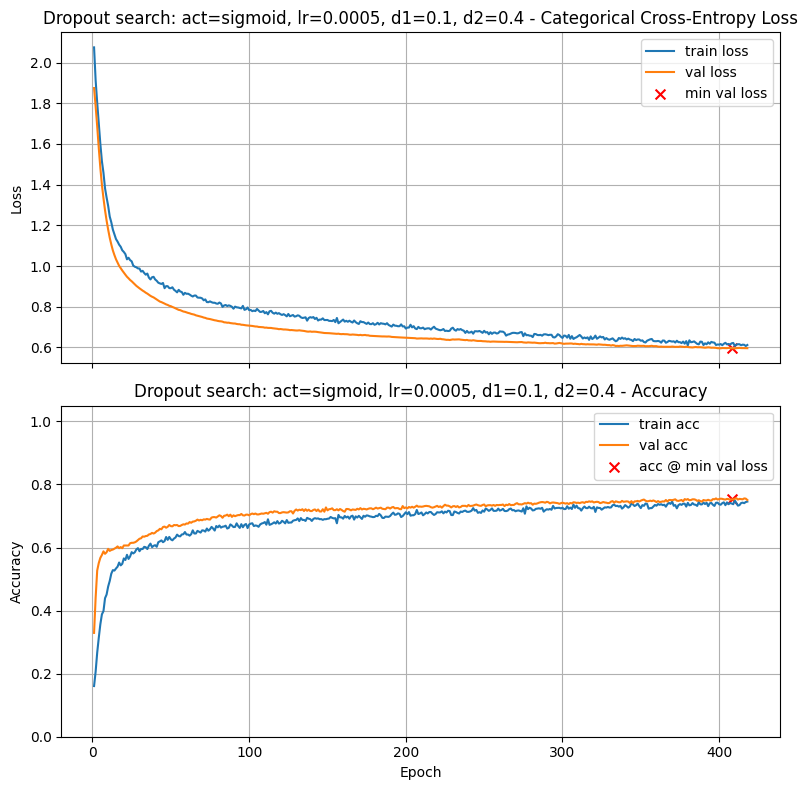

Final Training Loss:            0.6120
Final Training Accuracy:        0.7457
Final Validation Loss:          0.5962
Final Validation Accuracy:      0.7507
Minimum Validation Loss:        0.5953 (Epoch 408)
Validation Accuracy @ Min Loss: 0.7529

Test Loss: 0.6246
Test Accuracy: 0.7336

Validation-Test Gap (accuracy): 0.019286

Execution Time: 00:01:04

Dropout search: act=sigmoid, lr=0.0005, d1=0.1, d2=0.5



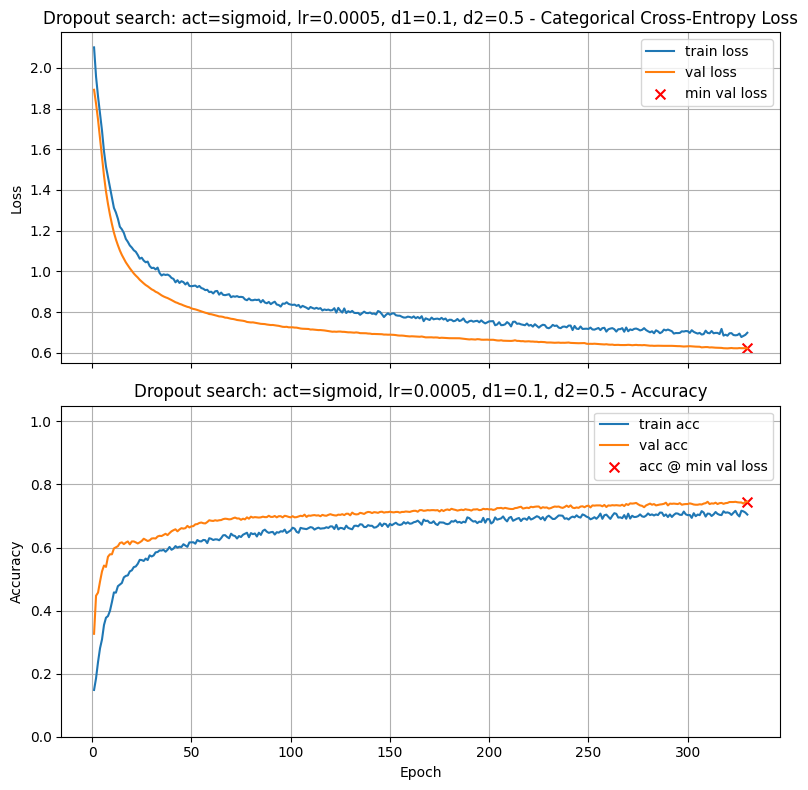

Final Training Loss:            0.6983
Final Training Accuracy:        0.7045
Final Validation Loss:          0.6216
Final Validation Accuracy:      0.7457
Minimum Validation Loss:        0.6216 (Epoch 330)
Validation Accuracy @ Min Loss: 0.7457

Test Loss: 0.6453
Test Accuracy: 0.7229

Validation-Test Gap (accuracy): 0.018571

Execution Time: 00:00:50

Dropout search: act=sigmoid, lr=0.0005, d1=0.2, d2=0.0



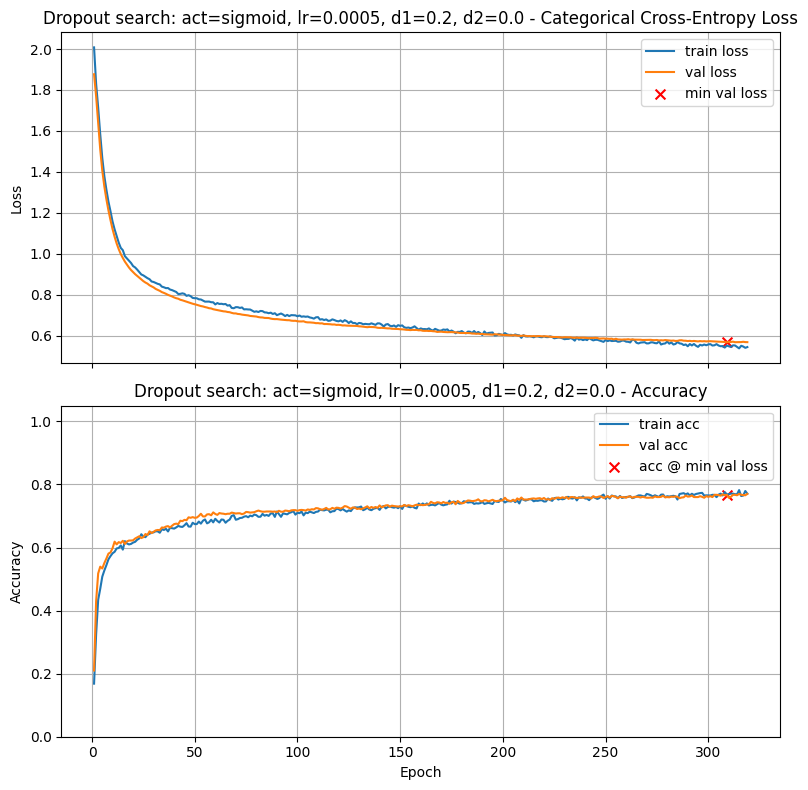

Final Training Loss:            0.5449
Final Training Accuracy:        0.7707
Final Validation Loss:          0.5690
Final Validation Accuracy:      0.7700
Minimum Validation Loss:        0.5685 (Epoch 309)
Validation Accuracy @ Min Loss: 0.7671

Test Loss: 0.5894
Test Accuracy: 0.7450

Validation-Test Gap (accuracy): 0.022143

Execution Time: 00:00:48

Dropout search: act=sigmoid, lr=0.0005, d1=0.2, d2=0.1



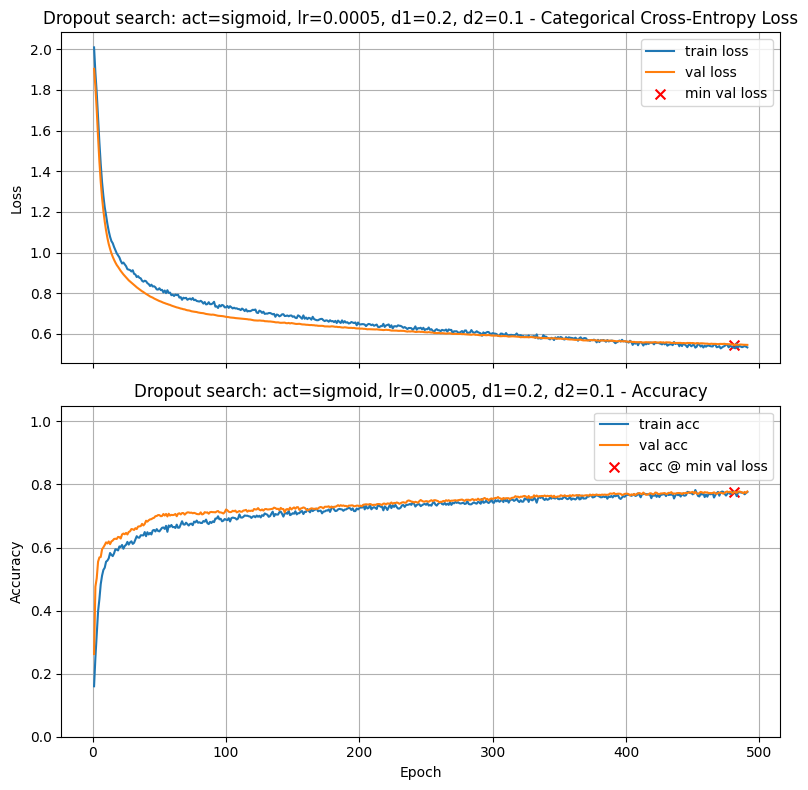

Final Training Loss:            0.5337
Final Training Accuracy:        0.7760
Final Validation Loss:          0.5460
Final Validation Accuracy:      0.7779
Minimum Validation Loss:        0.5457 (Epoch 481)
Validation Accuracy @ Min Loss: 0.7764

Test Loss: 0.5692
Test Accuracy: 0.7650

Validation-Test Gap (accuracy): 0.011429

Execution Time: 00:01:18

Dropout search: act=sigmoid, lr=0.0005, d1=0.2, d2=0.2



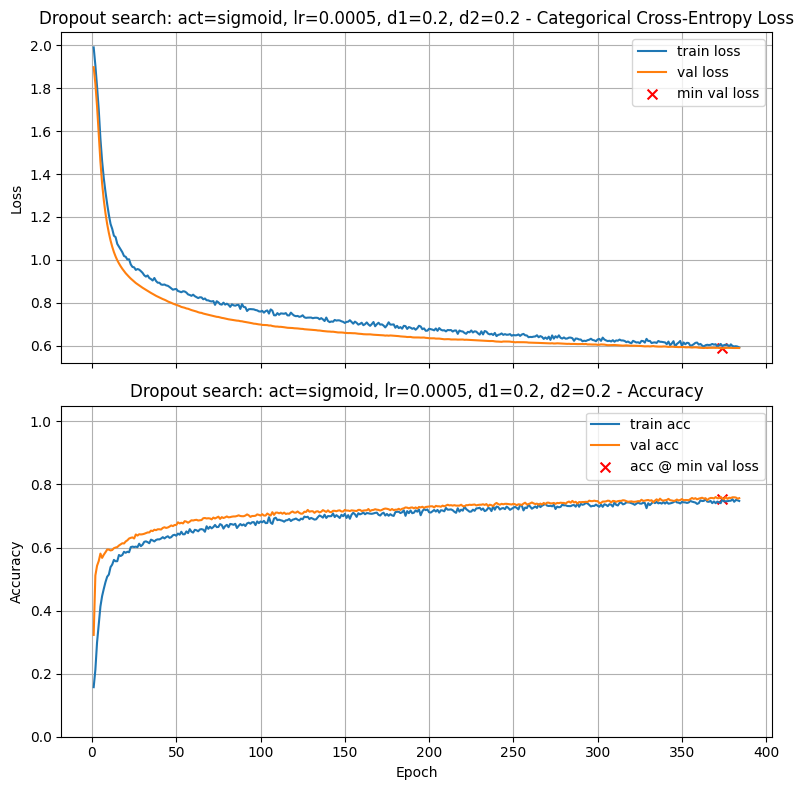

Final Training Loss:            0.5914
Final Training Accuracy:        0.7476
Final Validation Loss:          0.5888
Final Validation Accuracy:      0.7564
Minimum Validation Loss:        0.5872 (Epoch 374)
Validation Accuracy @ Min Loss: 0.7550

Test Loss: 0.6040
Test Accuracy: 0.7414

Validation-Test Gap (accuracy): 0.013571

Execution Time: 00:01:01

Dropout search: act=sigmoid, lr=0.0005, d1=0.2, d2=0.3



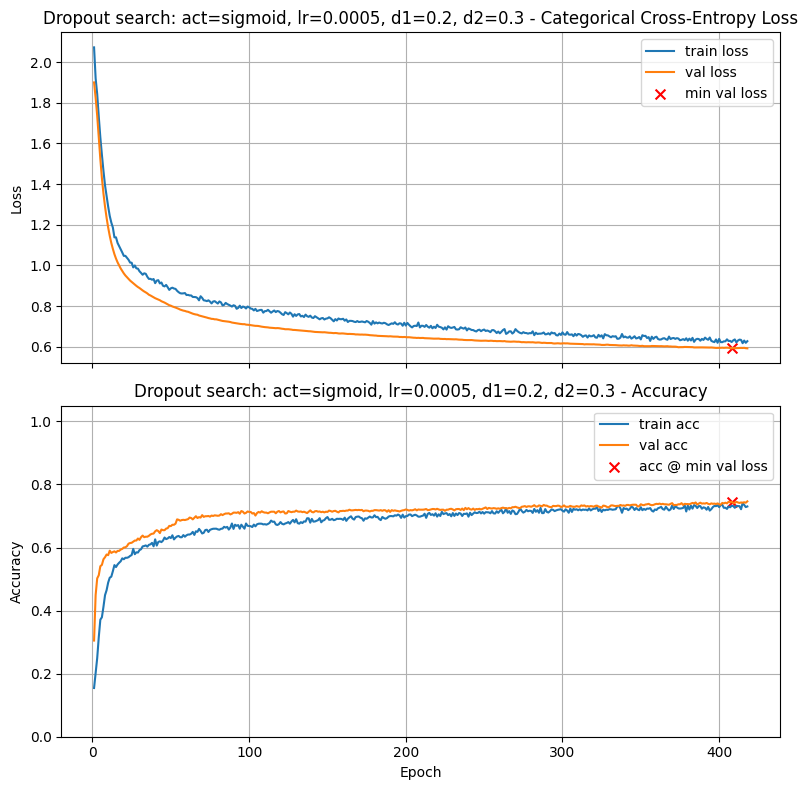

Final Training Loss:            0.6270
Final Training Accuracy:        0.7302
Final Validation Loss:          0.5919
Final Validation Accuracy:      0.7464
Minimum Validation Loss:        0.5916 (Epoch 408)
Validation Accuracy @ Min Loss: 0.7450

Test Loss: 0.6133
Test Accuracy: 0.7357

Validation-Test Gap (accuracy): 0.009286

Execution Time: 00:01:06

Dropout search: act=sigmoid, lr=0.0005, d1=0.2, d2=0.4



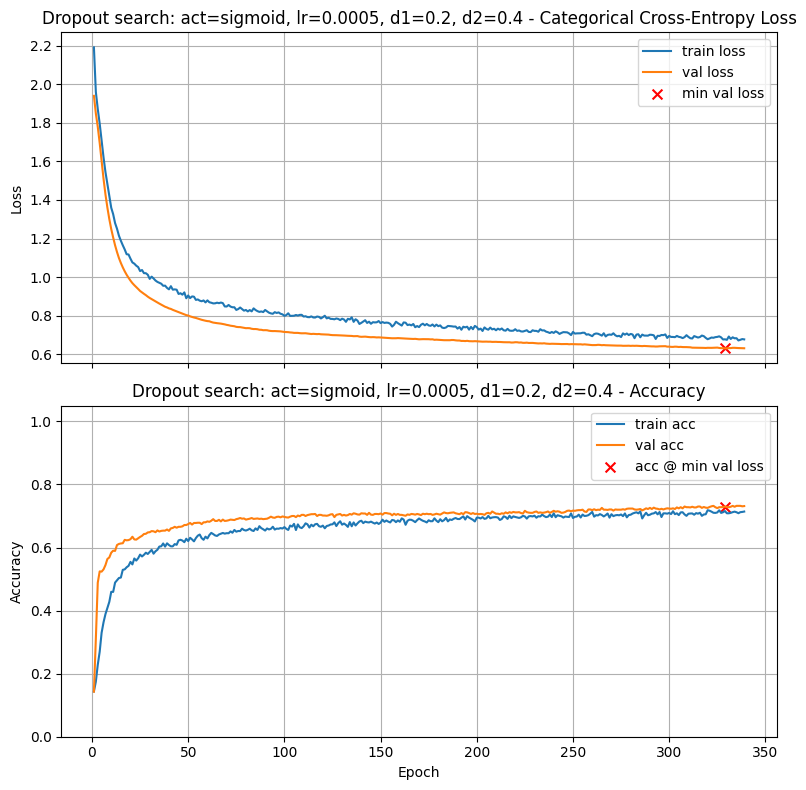

Final Training Loss:            0.6776
Final Training Accuracy:        0.7140
Final Validation Loss:          0.6316
Final Validation Accuracy:      0.7314
Minimum Validation Loss:        0.6310 (Epoch 329)
Validation Accuracy @ Min Loss: 0.7300

Test Loss: 0.6518
Test Accuracy: 0.7236

Validation-Test Gap (accuracy): 0.006429

Execution Time: 00:00:54

Dropout search: act=sigmoid, lr=0.0005, d1=0.2, d2=0.5



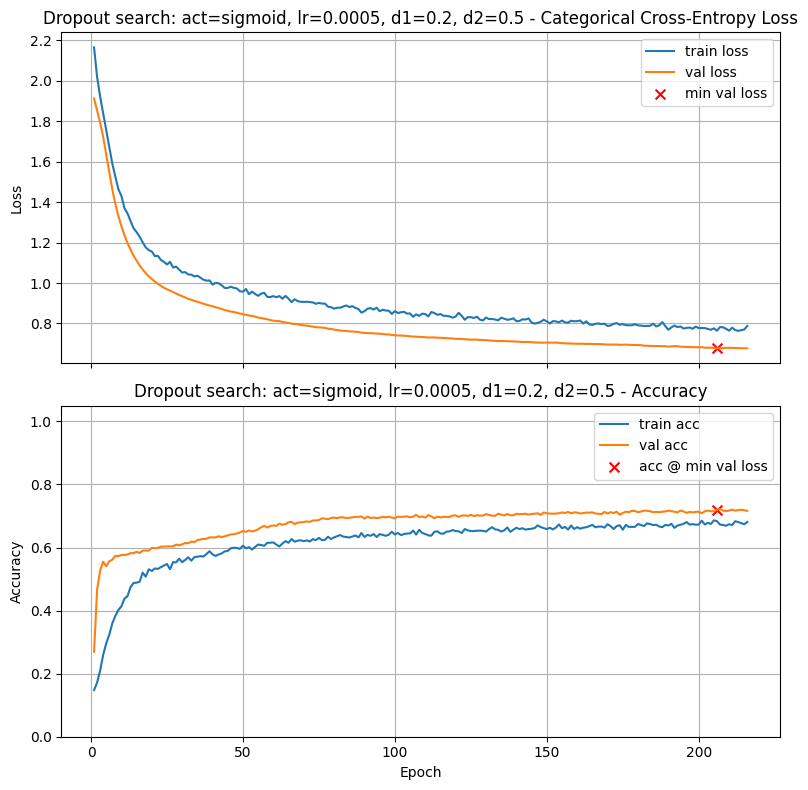

Final Training Loss:            0.7879
Final Training Accuracy:        0.6810
Final Validation Loss:          0.6769
Final Validation Accuracy:      0.7164
Minimum Validation Loss:        0.6769 (Epoch 206)
Validation Accuracy @ Min Loss: 0.7200

Test Loss: 0.6925
Test Accuracy: 0.7014

Validation-Test Gap (accuracy): 0.018571

Execution Time: 00:00:34


In [29]:
# Your code here. Add as many cells as you need. 
best_activation = "sigmoid"
best_lr = 5e-4

n_inputs = X_train.shape[1]
n_classes = len(np.unique(y_train))

W1, W2 = 64, 32
l2_lambda = 0.0

drop1_list = [0.0, 0.1, 0.2]
drop2_list = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]

def best_val_acc_from_history(hist):
    best_idx = int(np.argmin(hist.history["val_loss"]))
    best_vloss = float(hist.history["val_loss"][best_idx])
    best_vacc  = float(hist.history["val_accuracy"][best_idx])
    return best_idx, best_vloss, best_vacc

results_do = {} 

for d1 in drop1_list:
    for d2 in drop2_list:
        layer_list = [
            (W1, best_activation, l2_lambda, d1),
            (W2, best_activation, l2_lambda, d2),
        ]
        model = build_model(n_inputs, layer_list, n_classes)

        title = f"Dropout search: act={best_activation}, lr={best_lr}, d1={d1}, d2={d2}"
        hist = train_and_test(
            model,
            epochs=500,
            lr_schedule=best_lr,
            title=title,
            return_history=True,
            verbose=0
        )

        idx, vloss, vacc = best_val_acc_from_history(hist)
        results_do[(d1, d2)] = {
            "best_epoch": idx + 1,
            "val_loss": vloss,
            "val_acc": vacc
        }

In [30]:
sorted_configs = sorted(results_do.items(), key=lambda kv: kv[1]["val_acc"], reverse=True)

print("\nTop dropout configurations by val_acc at MIN val_loss:")
for (d1, d2), r in sorted_configs[:10]:
    print(f"d1={d1:.1f}, d2={d2:.1f} | best_epoch={r['best_epoch']:>3d} | val_loss={r['val_loss']:.4f} | val_acc={r['val_acc']:.4f}")

best_config, best_metrics = sorted_configs[0]
best_d1, best_d2 = best_config
print(f"\nBEST dropout config: d1={best_d1:.1f}, d2={best_d2:.1f}  (val_acc={best_metrics['val_acc']:.4f})")


Top dropout configurations by val_acc at MIN val_loss:
d1=0.1, d2=0.0 | best_epoch=448 | val_loss=0.5433 | val_acc=0.7807
d1=0.1, d2=0.1 | best_epoch=423 | val_loss=0.5574 | val_acc=0.7771
d1=0.2, d2=0.1 | best_epoch=481 | val_loss=0.5457 | val_acc=0.7764
d1=0.0, d2=0.0 | best_epoch=303 | val_loss=0.5613 | val_acc=0.7686
d1=0.0, d2=0.1 | best_epoch=280 | val_loss=0.5702 | val_acc=0.7671
d1=0.2, d2=0.0 | best_epoch=309 | val_loss=0.5685 | val_acc=0.7671
d1=0.0, d2=0.3 | best_epoch=343 | val_loss=0.5714 | val_acc=0.7607
d1=0.0, d2=0.2 | best_epoch=309 | val_loss=0.5785 | val_acc=0.7586
d1=0.1, d2=0.2 | best_epoch=333 | val_loss=0.5798 | val_acc=0.7550
d1=0.1, d2=0.3 | best_epoch=311 | val_loss=0.5986 | val_acc=0.7550

BEST dropout config: d1=0.1, d2=0.0  (val_acc=0.7807)


In [31]:
# Set a3a to the pair (dropout_rate_64,dropout_rate_32) of dropout rates for the two hidden layers which provided the best 
# validation accuracy at the epoch of minimum validation loss

a3a = (0.1,0.0)             # Replace (0.0,0.0) with your answer

In [32]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3a = {a3a}') 

a3a = (0.1, 0.0)


In [33]:
# Set a3b to the validation accuracy found by this best pair of dropout rates

a3b = 0.7757             # Replace 0.0 with your answer

In [34]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3b = {a3b:.4f}') 

a3b = 0.7757


### Problem Four: L2 Regularization

In this problem, you will explore how **L2 regularization** (also called *weight decay*) can help prevent overfitting in neural networks. There are no absolute rules, but some useful heuristics are:

* Start simple by using the **same λ in both hidden layers**, with values:

  ```
      1e-4, 1e-3, 1e-2
  ```

* If validation results suggest underfitting in the first layer or persistent overfitting in the later one, then try adjusting per layer, for example:

  * First hidden layer: λ = 1e-4
  * Second hidden layer: λ = 1e-3

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**, but **without dropout**.
* Investigate at least the four cases suggested (three with the same λ and one with different λ values). You may also consider additional combinations.
* Identify which configuration produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.



L2 search (no dropout): act=sigmoid, lr=0.0005, l2_1=0.0001, l2_2=0.0001



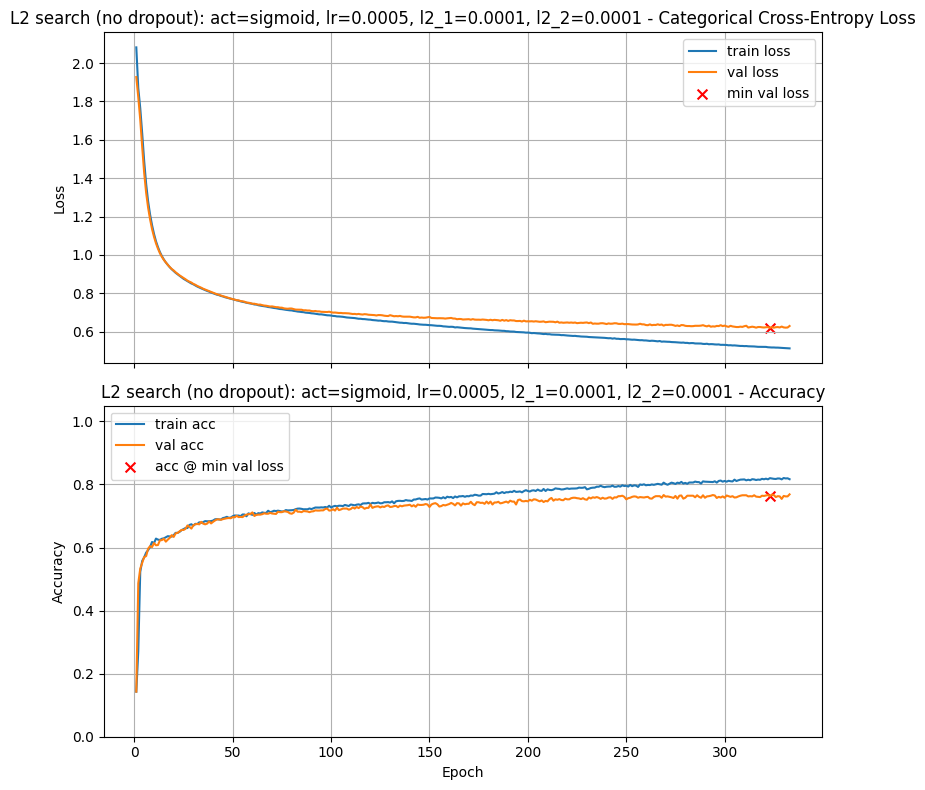

Final Training Loss:            0.5132
Final Training Accuracy:        0.8167
Final Validation Loss:          0.6299
Final Validation Accuracy:      0.7686
Minimum Validation Loss:        0.6199 (Epoch 323)
Validation Accuracy @ Min Loss: 0.7629

Test Loss: 0.6388
Test Accuracy: 0.7593

Validation-Test Gap (accuracy): 0.003571

Execution Time: 00:00:50

L2 search (no dropout): act=sigmoid, lr=0.0005, l2_1=0.001, l2_2=0.001



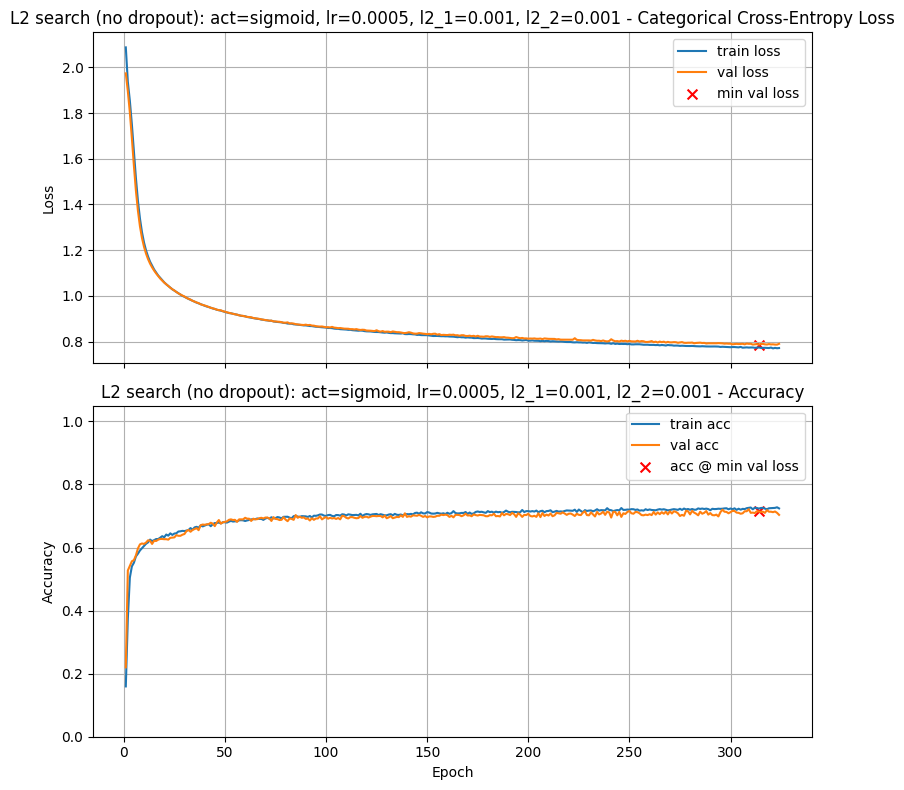

Final Training Loss:            0.7717
Final Training Accuracy:        0.7240
Final Validation Loss:          0.7903
Final Validation Accuracy:      0.7036
Minimum Validation Loss:        0.7866 (Epoch 314)
Validation Accuracy @ Min Loss: 0.7143

Test Loss: 0.8066
Test Accuracy: 0.7157

Validation-Test Gap (accuracy): 0.001429

Execution Time: 00:00:49

L2 search (no dropout): act=sigmoid, lr=0.0005, l2_1=0.01, l2_2=0.01



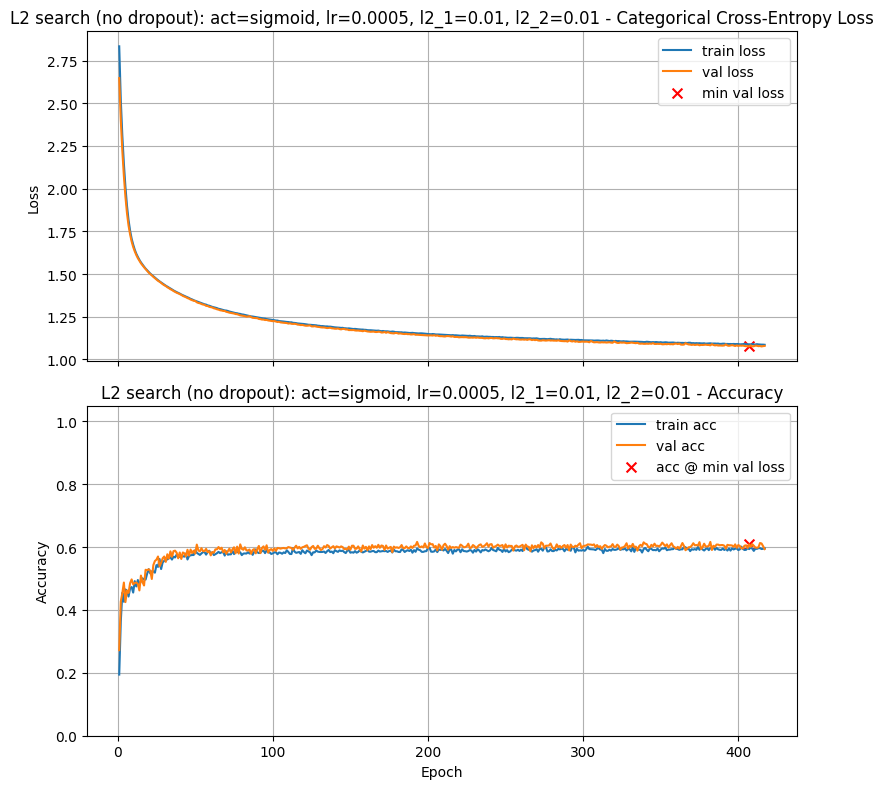

Final Training Loss:            1.0858
Final Training Accuracy:        0.5964
Final Validation Loss:          1.0792
Final Validation Accuracy:      0.5936
Minimum Validation Loss:        1.0759 (Epoch 407)
Validation Accuracy @ Min Loss: 0.6086

Test Loss: 1.0948
Test Accuracy: 0.6050

Validation-Test Gap (accuracy): 0.003571

Execution Time: 00:01:00

L2 search (no dropout): act=sigmoid, lr=0.0005, l2_1=0.0001, l2_2=0.001



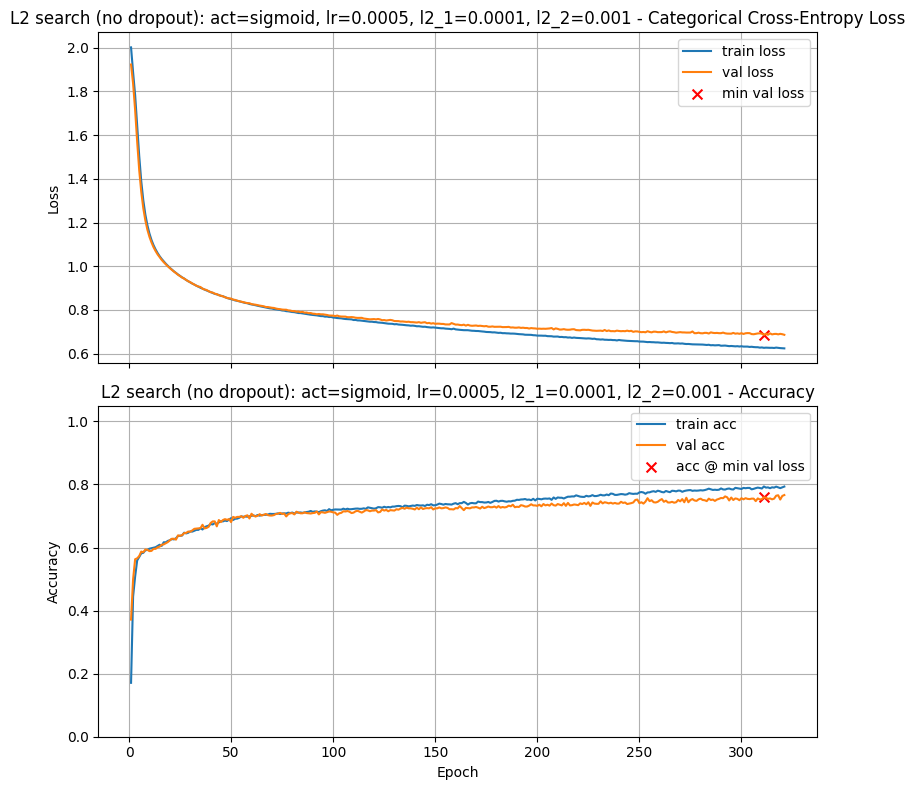

Final Training Loss:            0.6242
Final Training Accuracy:        0.7933
Final Validation Loss:          0.6863
Final Validation Accuracy:      0.7664
Minimum Validation Loss:        0.6863 (Epoch 311)
Validation Accuracy @ Min Loss: 0.7593

Test Loss: 0.7093
Test Accuracy: 0.7471

Validation-Test Gap (accuracy): 0.012143

Execution Time: 00:00:47


In [35]:
# Your code here. Add as many cells as you need. 
best_activation = "sigmoid"
best_lr = 5e-4

n_inputs = X_train.shape[1]
n_classes = len(np.unique(y_train))

W1, W2 = 64, 32
dropout_rate_1 = 0.0
dropout_rate_2 = 0.0

l2_configs = [
    (1e-4, 1e-4),
    (1e-3, 1e-3),
    (1e-2, 1e-2),
    (1e-4, 1e-3),
]

def best_val_acc_from_history(hist):
    best_idx = int(np.argmin(hist.history["val_loss"]))
    best_vloss = float(hist.history["val_loss"][best_idx])
    best_vacc  = float(hist.history["val_accuracy"][best_idx])
    return best_idx, best_vloss, best_vacc

results_l2 = {}

for l2_1, l2_2 in l2_configs:
    layer_list = [
        (W1, best_activation, l2_1, dropout_rate_1),
        (W2, best_activation, l2_2, dropout_rate_2),
    ]
    model = build_model(n_inputs, layer_list, n_classes)

    title = f"L2 search (no dropout): act={best_activation}, lr={best_lr}, l2_1={l2_1:g}, l2_2={l2_2:g}"
    hist = train_and_test(
        model,
        epochs=500,
        lr_schedule=best_lr,
        title=title,
        return_history=True,
        verbose=0
    )

    idx, vloss, vacc = best_val_acc_from_history(hist)
    results_l2[(l2_1, l2_2)] = {"best_epoch": idx + 1, "val_loss": vloss, "val_acc": vacc}

In [36]:
print("\nValidation accuracy at epoch of MIN val_loss (early-stopping selected):")
for (l2_1, l2_2) in l2_configs:
    r = results_l2[(l2_1, l2_2)]
    print(f"l2_1={l2_1:>5g}, l2_2={l2_2:>5g} | best_epoch={r['best_epoch']:>3d} | val_loss={r['val_loss']:.4f} | val_acc={r['val_acc']:.4f}")

best_cfg = max(results_l2.keys(), key=lambda k: results_l2[k]["val_acc"])
print(f"\nBest L2 config: l2_1={best_cfg[0]:g}, l2_2={best_cfg[1]:g} (val_acc={results_l2[best_cfg]['val_acc']:.4f})")


Validation accuracy at epoch of MIN val_loss (early-stopping selected):
l2_1=0.0001, l2_2=0.0001 | best_epoch=323 | val_loss=0.6199 | val_acc=0.7629
l2_1=0.001, l2_2=0.001 | best_epoch=314 | val_loss=0.7866 | val_acc=0.7143
l2_1= 0.01, l2_2= 0.01 | best_epoch=407 | val_loss=1.0759 | val_acc=0.6086
l2_1=0.0001, l2_2=0.001 | best_epoch=311 | val_loss=0.6863 | val_acc=0.7593

Best L2 config: l2_1=0.0001, l2_2=0.0001 (val_acc=0.7629)


In [37]:
# Set a4a to the pair (L2_lambda_64,L2_lambda_32) of the L2 lambdas for the two hidden layers which provided the best 
# validation accuracy at the epoch of minimum validation loss

a4a = (0.0001,0.0001)             # Replace (0.0,0.0) with your answer

In [38]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4a = {a4a}') 

a4a = (0.0001, 0.0001)


In [39]:
# Set a4b to the validation accuracy found by this best pair of lambdas

a4b = 0.7671             # Replace 0.0 with your answer

In [40]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4b = {a4b:.4f}') 

a4b = 0.7671


### Problem Five: Combining Dropout with L2 Regularization

In this problem, you will explore how **dropout** and **L2 regularization** can work together to prevent overfitting. These two methods complement each other, but must be balanced carefully. A useful rule of thumb is:

* If dropout is **high**, use a **smaller λ**.
* If dropout is **low**, you can afford a **larger λ**.

**Steps to follow:**

* Build and train the **baseline model** using the **activation function from Problem One** and the **learning rate from Problem Two**.
* Investigate combinations of dropout and L2:

  * First, use the **dropout rate you identified in Problem Three** as a baseline.
  * Then, add L2 to both hidden layers with values:

    ```
        1e-4, 1e-3, 1e-2
    ```

    while keeping dropout fixed.
  * Finally, try **reducing dropout slightly** when L2 is added to see if performance improves.
  * [Optional] You may wish to investigate other combinations not covered here; for example, promising but not optimal choices of dropout rates may provide overall better performance when combines with L2 Regulari 
* Identify which combination produces the **best validation accuracy** at the epoch of **minimum validation loss**.
* Answer the graded questions.



In [41]:
# Your code here. Add as many cells as you need.
best_activation = "sigmoid"
best_lr = 5e-4
best_d1 = 0.1
best_d2 = 0.0

n_inputs = X_train.shape[1]
n_classes = len(np.unique(y_train))

W1, W2 = 64, 32

def best_val_acc_from_history(hist):
    best_idx = int(np.argmin(hist.history["val_loss"]))
    best_vloss = float(hist.history["val_loss"][best_idx])
    best_vacc  = float(hist.history["val_accuracy"][best_idx])
    return best_idx, best_vloss, best_vacc


=== Phase A: Fix dropout at Problem 3 best, add L2 (same in both layers) ===

Combo A: act=sigmoid, lr=0.0005, d=(0.1,0.0), l2=0.0001



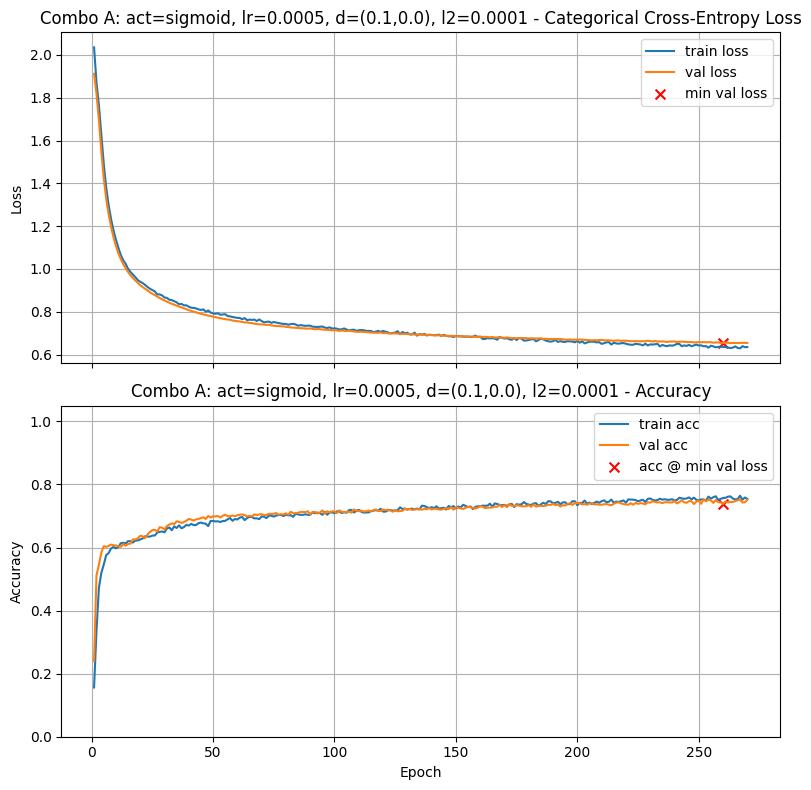

Final Training Loss:            0.6350
Final Training Accuracy:        0.7540
Final Validation Loss:          0.6538
Final Validation Accuracy:      0.7514
Minimum Validation Loss:        0.6535 (Epoch 260)
Validation Accuracy @ Min Loss: 0.7386

Test Loss: 0.6757
Test Accuracy: 0.7336

Validation-Test Gap (accuracy): 0.005000

Execution Time: 00:00:43

Combo A: act=sigmoid, lr=0.0005, d=(0.1,0.0), l2=0.001



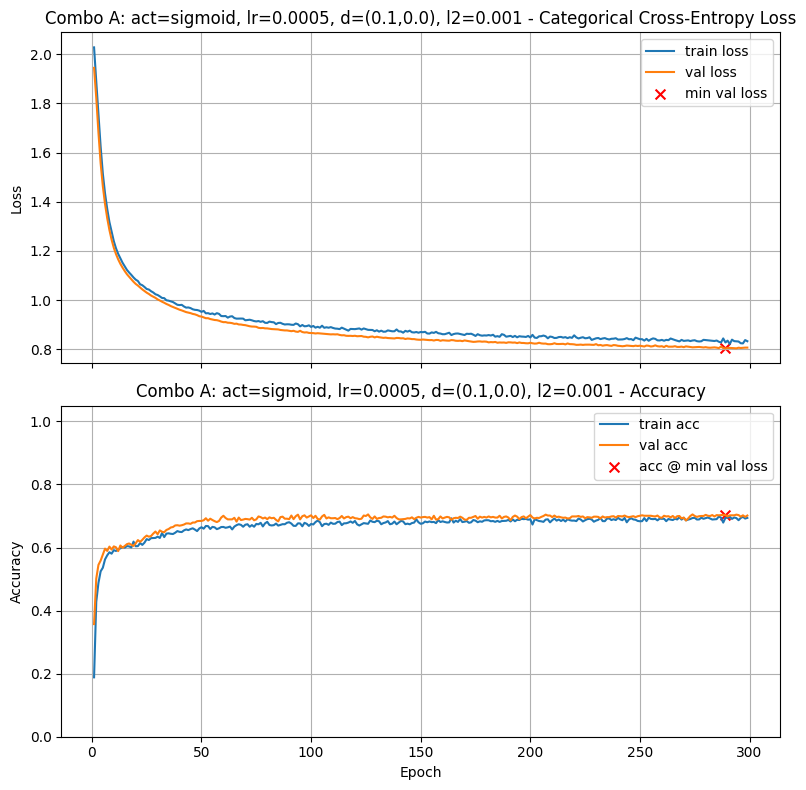

Final Training Loss:            0.8324
Final Training Accuracy:        0.6940
Final Validation Loss:          0.8064
Final Validation Accuracy:      0.7014
Minimum Validation Loss:        0.8032 (Epoch 289)
Validation Accuracy @ Min Loss: 0.7029

Test Loss: 0.8237
Test Accuracy: 0.6993

Validation-Test Gap (accuracy): 0.003571

Execution Time: 00:00:48

Combo A: act=sigmoid, lr=0.0005, d=(0.1,0.0), l2=0.01



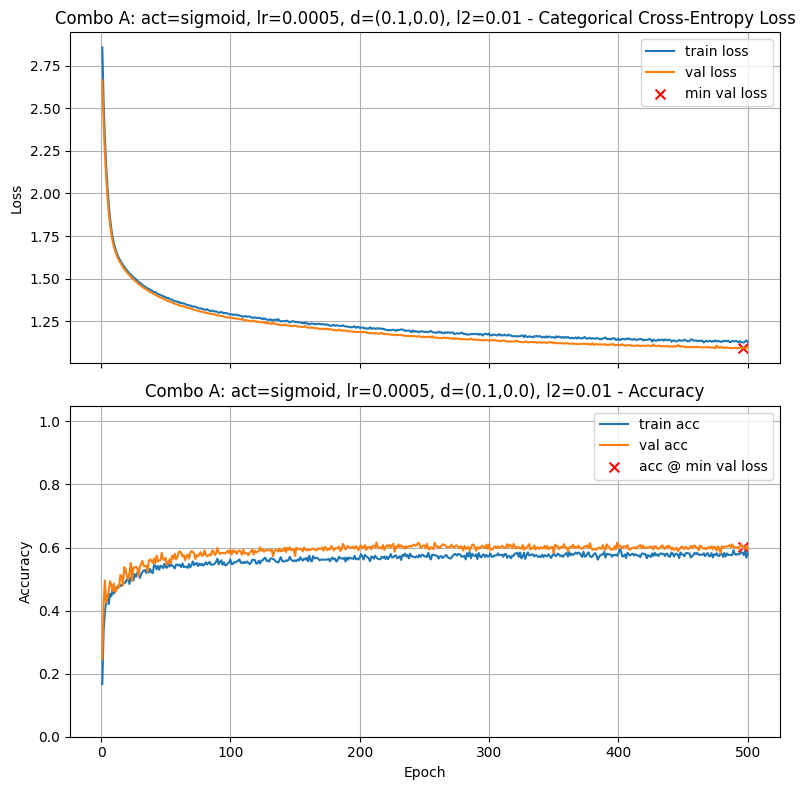

Final Training Loss:            1.1300
Final Training Accuracy:        0.5819
Final Validation Loss:          1.0962
Final Validation Accuracy:      0.5964
Minimum Validation Loss:        1.0914 (Epoch 496)
Validation Accuracy @ Min Loss: 0.6029

Test Loss: 1.1097
Test Accuracy: 0.5986

Validation-Test Gap (accuracy): 0.004286

Execution Time: 00:01:16


In [42]:
l2_values = [1e-4, 1e-3, 1e-2]
results_combo = {}

print("\n=== Phase A: Fix dropout at Problem 3 best, add L2 (same in both layers) ===")
for l2 in l2_values:
    layer_list = [
        (W1, best_activation, l2, best_d1),
        (W2, best_activation, l2, best_d2),
    ]
    model = build_model(n_inputs, layer_list, n_classes)

    title = f"Combo A: act={best_activation}, lr={best_lr}, d=({best_d1},{best_d2}), l2={l2:g}"
    hist = train_and_test(
        model,
        epochs=500,
        lr_schedule=best_lr,
        title=title,
        return_history=True,
        verbose=0
    )

    idx, vloss, vacc = best_val_acc_from_history(hist)
    results_combo[(best_d1, best_d2, l2, l2)] = {"best_epoch": idx + 1, "val_loss": vloss, "val_acc": vacc}


=== Phase B: Try reduced dropout (-0.1) when L2 is added ===

Combo B: act=sigmoid, lr=0.0005, d=(0.0,0.0), l2=0.0001



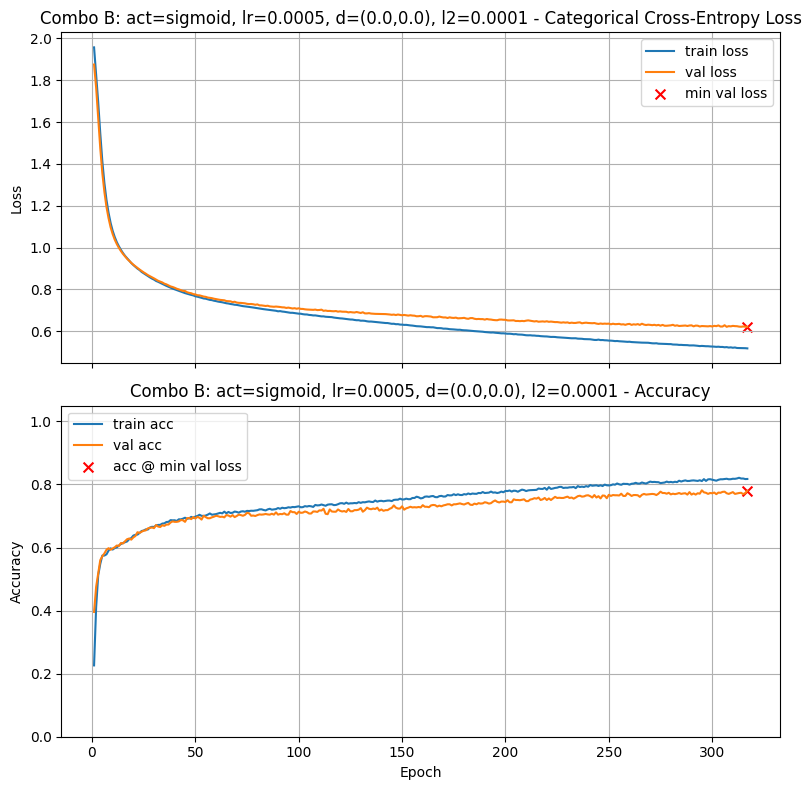

Final Training Loss:            0.5184
Final Training Accuracy:        0.8174
Final Validation Loss:          0.6214
Final Validation Accuracy:      0.7800
Minimum Validation Loss:        0.6214 (Epoch 317)
Validation Accuracy @ Min Loss: 0.7800

Test Loss: 0.6300
Test Accuracy: 0.7657

Validation-Test Gap (accuracy): 0.006429

Execution Time: 00:00:45

Combo B: act=sigmoid, lr=0.0005, d=(0.1,0.0), l2=0.0001



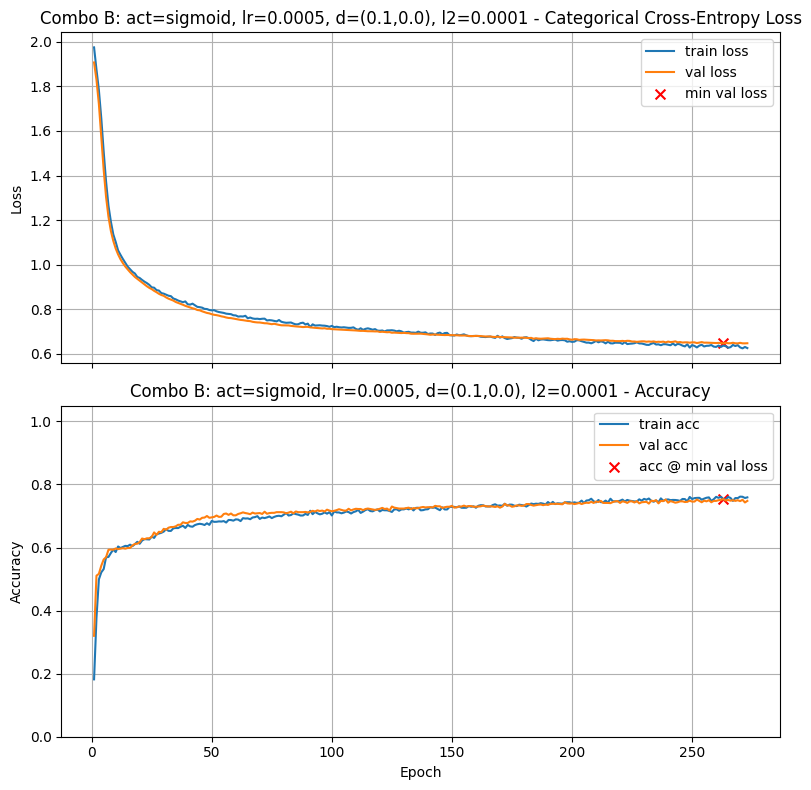

Final Training Loss:            0.6254
Final Training Accuracy:        0.7590
Final Validation Loss:          0.6471
Final Validation Accuracy:      0.7479
Minimum Validation Loss:        0.6463 (Epoch 263)
Validation Accuracy @ Min Loss: 0.7536

Test Loss: 0.6662
Test Accuracy: 0.7436

Validation-Test Gap (accuracy): 0.010000

Execution Time: 00:00:41

Combo B: act=sigmoid, lr=0.0005, d=(0.0,0.0), l2=0.001



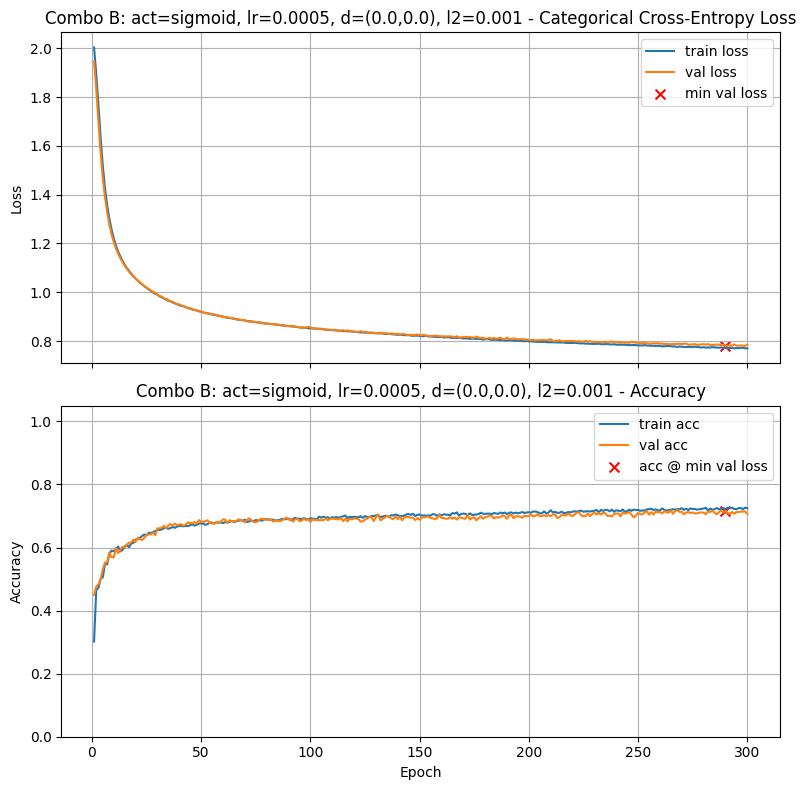

Final Training Loss:            0.7700
Final Training Accuracy:        0.7243
Final Validation Loss:          0.7861
Final Validation Accuracy:      0.7064
Minimum Validation Loss:        0.7803 (Epoch 290)
Validation Accuracy @ Min Loss: 0.7164

Test Loss: 0.8030
Test Accuracy: 0.7093

Validation-Test Gap (accuracy): 0.007143

Execution Time: 00:00:43

Combo B: act=sigmoid, lr=0.0005, d=(0.1,0.0), l2=0.001



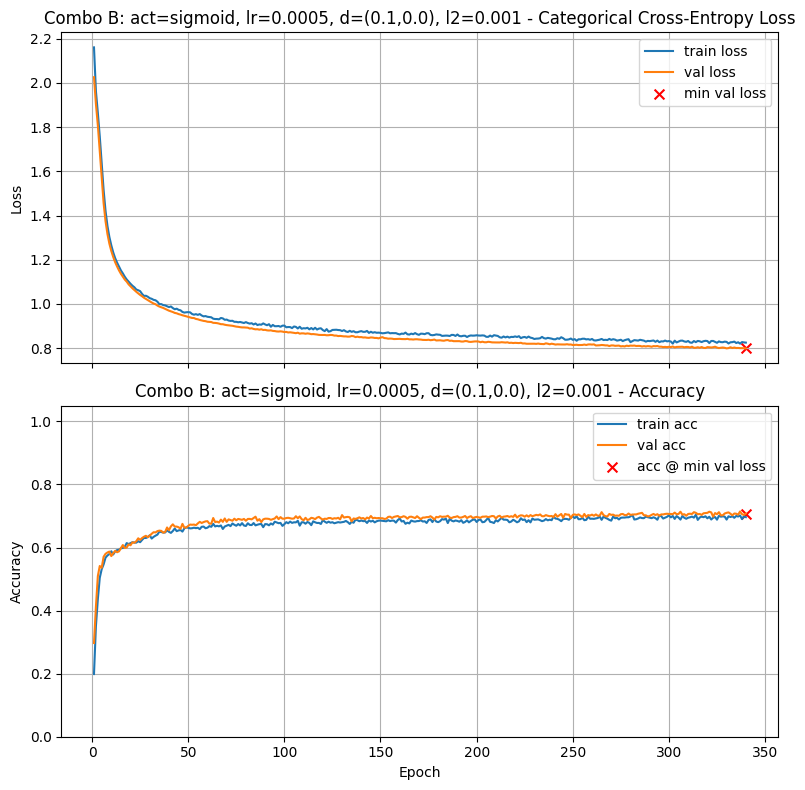

Final Training Loss:            0.8248
Final Training Accuracy:        0.6964
Final Validation Loss:          0.7987
Final Validation Accuracy:      0.7079
Minimum Validation Loss:        0.7987 (Epoch 340)
Validation Accuracy @ Min Loss: 0.7079

Test Loss: 0.8170
Test Accuracy: 0.7100

Validation-Test Gap (accuracy): 0.000000

Execution Time: 00:00:51

Combo B: act=sigmoid, lr=0.0005, d=(0.0,0.0), l2=0.01



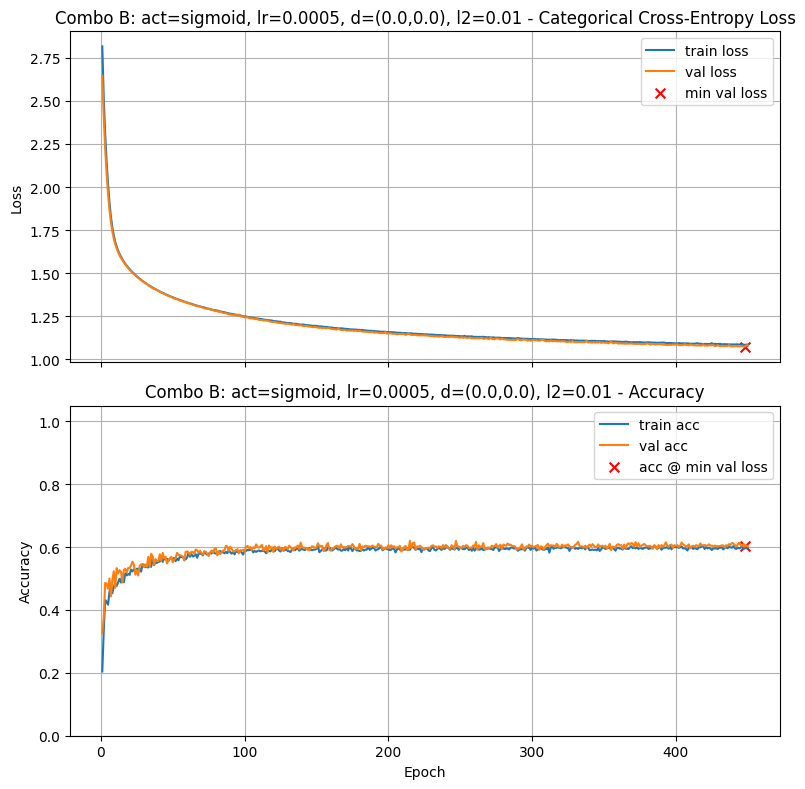

Final Training Loss:            1.0852
Final Training Accuracy:        0.5981
Final Validation Loss:          1.0808
Final Validation Accuracy:      0.6021
Minimum Validation Loss:        1.0746 (Epoch 448)
Validation Accuracy @ Min Loss: 0.6029

Test Loss: 1.0953
Test Accuracy: 0.6000

Validation-Test Gap (accuracy): 0.011429

Execution Time: 00:01:02

Combo B: act=sigmoid, lr=0.0005, d=(0.1,0.0), l2=0.01



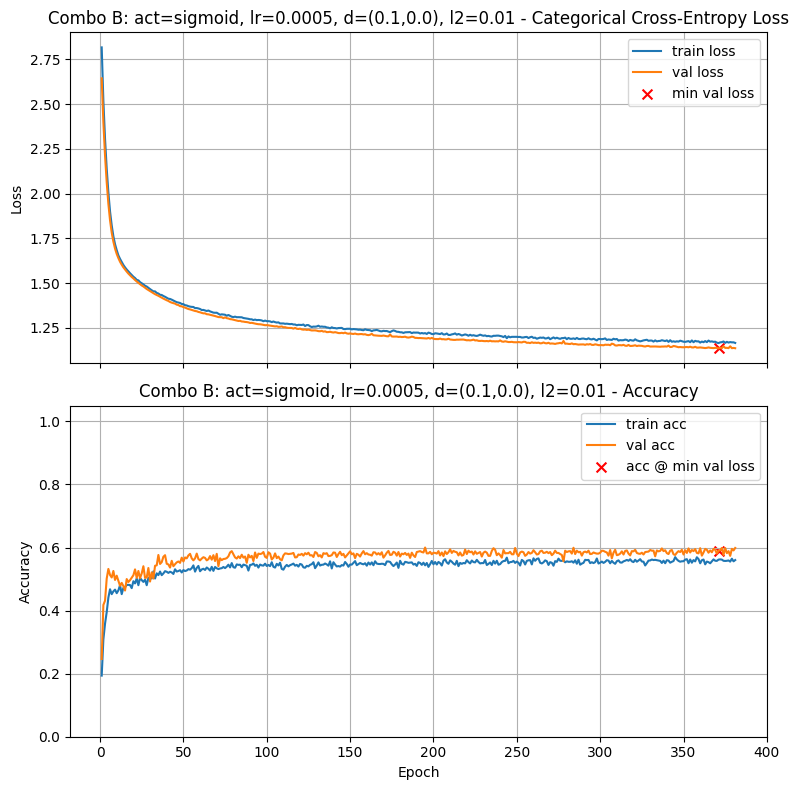

Final Training Loss:            1.1656
Final Training Accuracy:        0.5602
Final Validation Loss:          1.1362
Final Validation Accuracy:      0.5986
Minimum Validation Loss:        1.1352 (Epoch 371)
Validation Accuracy @ Min Loss: 0.5900

Test Loss: 1.1529
Test Accuracy: 0.5850

Validation-Test Gap (accuracy): 0.005000

Execution Time: 00:00:54


In [43]:
reduced_d1_options = sorted({max(0.0, best_d1 - 0.1), best_d1})
reduced_d2_options = sorted({max(0.0, best_d2 - 0.1), best_d2})

print("\n=== Phase B: Try reduced dropout (-0.1) when L2 is added ===")
for l2 in l2_values:
    for d1 in reduced_d1_options:
        for d2 in reduced_d2_options:
            layer_list = [
                (W1, best_activation, l2, d1),
                (W2, best_activation, l2, d2),
            ]
            model = build_model(n_inputs, layer_list, n_classes)

            title = f"Combo B: act={best_activation}, lr={best_lr}, d=({d1},{d2}), l2={l2:g}"
            hist = train_and_test(
                model,
                epochs=500,
                lr_schedule=best_lr,
                title=title,
                return_history=True,
                verbose=0
            )

            idx, vloss, vacc = best_val_acc_from_history(hist)
            results_combo[(d1, d2, l2, l2)] = {"best_epoch": idx + 1, "val_loss": vloss, "val_acc": vacc}

In [44]:
best_key = max(results_combo.keys(), key=lambda k: results_combo[k]["val_acc"])
best_metrics = results_combo[best_key]
d1, d2, l2_1, l2_2 = best_key

print("\n=== Summary: Top combinations by val_acc at MIN val_loss ===")
top = sorted(results_combo.items(), key=lambda kv: kv[1]["val_acc"], reverse=True)[:10]
for (d1_, d2_, l21_, l22_), r in top:
    print(f"d=({d1_:.1f},{d2_:.1f}), l2=({l21_:g},{l22_:g}) | best_epoch={r['best_epoch']:>3d} | val_loss={r['val_loss']:.4f} | val_acc={r['val_acc']:.4f}")

print(f"\nBEST overall: d=({d1:.1f},{d2:.1f}), l2=({l2_1:g},{l2_2:g})  "
      f"(val_acc={best_metrics['val_acc']:.4f} at epoch {best_metrics['best_epoch']})")


=== Summary: Top combinations by val_acc at MIN val_loss ===
d=(0.0,0.0), l2=(0.0001,0.0001) | best_epoch=317 | val_loss=0.6214 | val_acc=0.7800
d=(0.1,0.0), l2=(0.0001,0.0001) | best_epoch=263 | val_loss=0.6463 | val_acc=0.7536
d=(0.0,0.0), l2=(0.001,0.001) | best_epoch=290 | val_loss=0.7803 | val_acc=0.7164
d=(0.1,0.0), l2=(0.001,0.001) | best_epoch=340 | val_loss=0.7987 | val_acc=0.7079
d=(0.0,0.0), l2=(0.01,0.01) | best_epoch=448 | val_loss=1.0746 | val_acc=0.6029
d=(0.1,0.0), l2=(0.01,0.01) | best_epoch=371 | val_loss=1.1352 | val_acc=0.5900

BEST overall: d=(0.0,0.0), l2=(0.0001,0.0001)  (val_acc=0.7800 at epoch 317)


In [45]:
# Set a5 to the validation accuracy found by this best combination of dropout and L2 regularization

a5 = 0.7757             # Replace 0.0 with your answer

In [46]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5 = {a5:.4f}') 

a5 = 0.7757


### Problem Six: Build and Train Your Best Model

In this final problem, you will design and train your **best-performing model** using the techniques explored in the previous problems. You may make your own choices for:

* **Model architecture** (number of layers, widths, etc.)
* **Learning rate**
* **Batch size** (a new hyperparameter not varied in earlier problems)
* **Dropout rates** in both layers
* **L2 λ values** in both layers
* **[Optional but strongly suggested]:** Learning rate scheduling, using either **Exponential Decay** or **Cosine Decay**.

  * For Exponential Decay, typical decay rates are **0.90–0.999**, with **0.95** often a good starting point.

**Steps to follow:**

* Build and train the model according to your design choices.
* Use early stopping as before to evaluate performance at the epoch of **minimum validation loss**.
* Answer the graded question.


In [47]:
# Your code here
best_activation = "sigmoid"
widths = [128, 64, 32]
dropouts = [0.1, 0.2, 0.3]
l2s = [1e-2, 3e-3, 1e-5]

batch_sizes = [32]

constant_lrs = [1e-3, 5e-4]

use_exp_decay = True 
exp_initial_lrs = [1e-3, 5e-4]
exp_decay_rates = [0.92, 0.96]
exp_decay_steps = None 

max_epochs = 500
patience = 10
min_delta = 1e-4

In [48]:
n_inputs = X_train.shape[1]
n_classes = len(np.unique(y_train))

def build_custom_model(n_inputs, widths, activation, l2s, dropouts, n_classes):
    assert len(widths) == len(l2s) == len(dropouts), "widths, l2s, dropouts must be same length"
    layers = [Input(shape=(n_inputs,))]
    for w, l2_lambda, d in zip(widths, l2s, dropouts):
        layers.append(Dense(w, activation=activation, kernel_regularizer=regularizers.l2(l2_lambda)))
        if d > 0:
            layers.append(Dropout(d))
    layers.append(Dense(n_classes, activation="softmax"))
    return models.Sequential(layers)

def best_val_acc_from_history(hist):
    best_idx = int(np.argmin(hist.history["val_loss"]))
    return {
        "best_epoch": best_idx + 1,
        "val_loss": float(hist.history["val_loss"][best_idx]),
        "val_acc":  float(hist.history["val_accuracy"][best_idx]),
    }   

In [49]:
def train_and_test_sched(model,
                         epochs=500,
                         lr_schedule=1e-3,
                         batch_size=64,
                         title="Learning Curves",
                         use_early_stopping=True,
                         patience=10,
                         min_delta=1e-4,
                         callbacks=[],
                         verbose=0):
    print(f"\n{title}\n")

    opt = Adam(learning_rate=lr_schedule)

    model.compile(optimizer=opt,
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        min_delta=min_delta,
        restore_best_weights=True,
        verbose=verbose
    )

    cbs = ([early_stop] + callbacks) if use_early_stopping else callbacks

    hist = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val, y_val),
        callbacks=cbs,
        verbose=verbose
    )

    plot_learning_curves(hist, title=title)

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")

    best = best_val_acc_from_history(hist)
    print(f"\nVal acc at min val_loss: {best['val_acc']:.4f} (epoch {best['best_epoch']})")
    print(f"Validation-Test Gap (accuracy): {abs(best['val_acc'] - test_acc):.6f}")

    return hist, best, (test_loss, test_acc)




P6 ConstLR | arch=[128, 64, 32] | act=sigmoid | bs=32 | lr=0.001



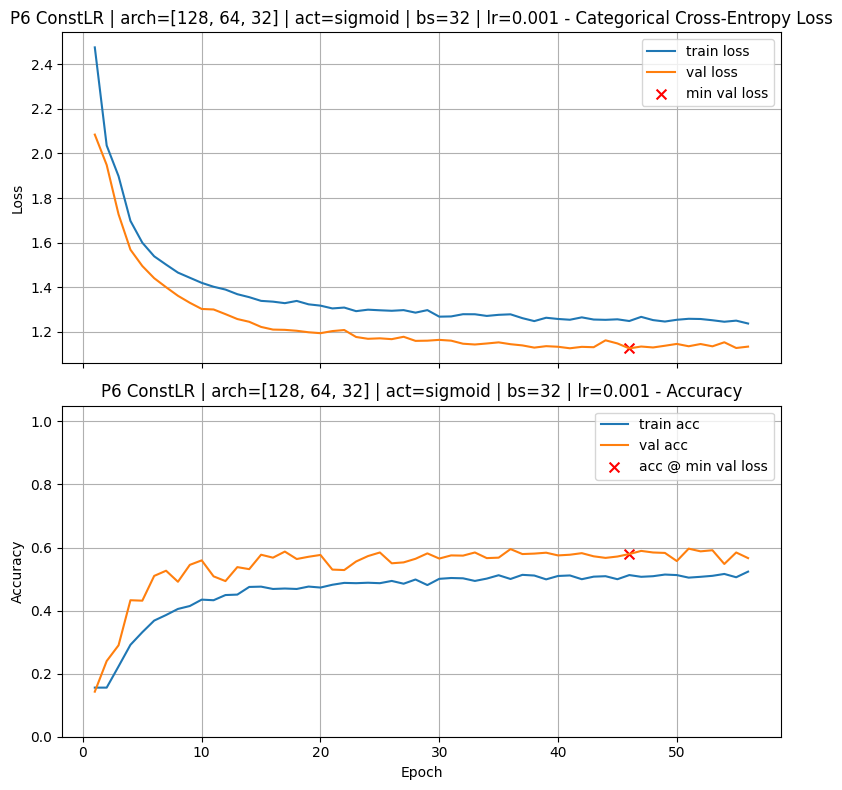

Final Training Loss:            1.2378
Final Training Accuracy:        0.5236
Final Validation Loss:          1.1342
Final Validation Accuracy:      0.5664
Minimum Validation Loss:        1.1263 (Epoch 46)
Validation Accuracy @ Min Loss: 0.5793

Test Loss: 1.1455
Test Accuracy: 0.5779

Val acc at min val_loss: 0.5793 (epoch 46)
Validation-Test Gap (accuracy): 0.001429

P6 ConstLR | arch=[128, 64, 32] | act=sigmoid | bs=32 | lr=0.0005



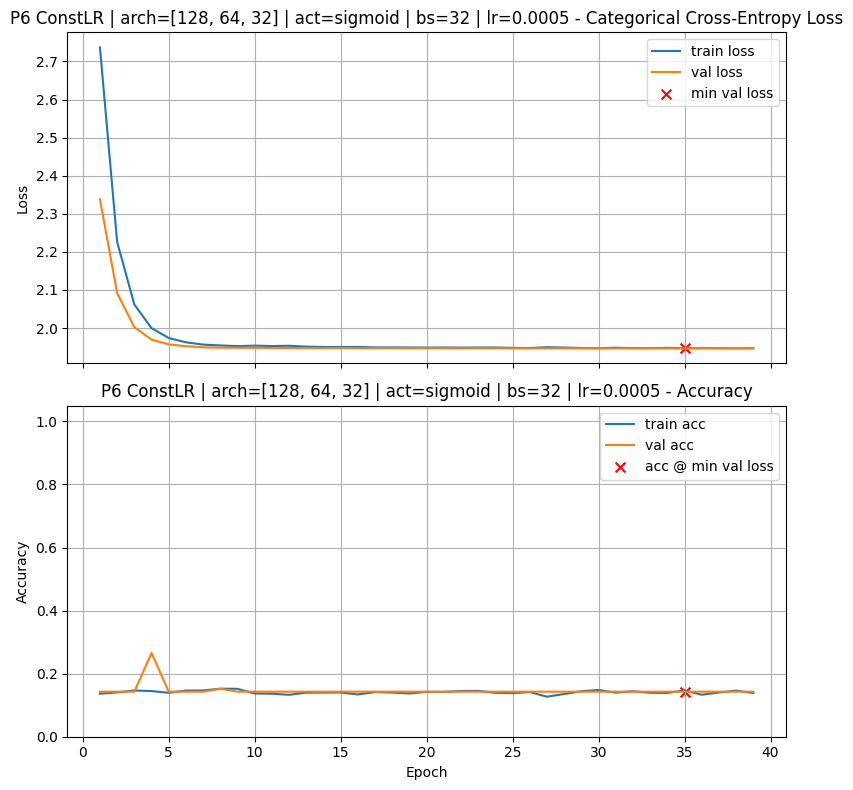

Final Training Loss:            1.9471
Final Training Accuracy:        0.1386
Final Validation Loss:          1.9466
Final Validation Accuracy:      0.1429
Minimum Validation Loss:        1.9466 (Epoch 35)
Validation Accuracy @ Min Loss: 0.1429

Test Loss: 1.9466
Test Accuracy: 0.1429

Val acc at min val_loss: 0.1429 (epoch 35)
Validation-Test Gap (accuracy): 0.000000

P6 ExpDecay | arch=[128, 64, 32] | act=sigmoid | bs=32 | init_lr=0.001 | rate=0.92



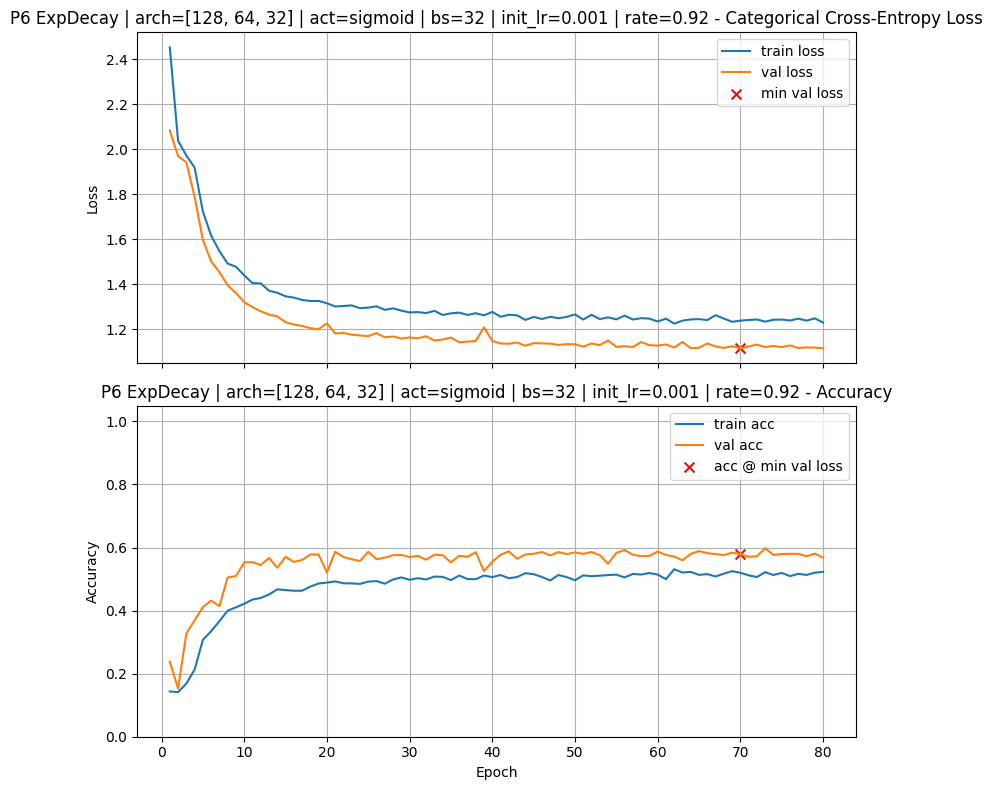

Final Training Loss:            1.2289
Final Training Accuracy:        0.5229
Final Validation Loss:          1.1151
Final Validation Accuracy:      0.5679
Minimum Validation Loss:        1.1145 (Epoch 70)
Validation Accuracy @ Min Loss: 0.5793

Test Loss: 1.1319
Test Accuracy: 0.5764

Val acc at min val_loss: 0.5793 (epoch 70)
Validation-Test Gap (accuracy): 0.002857

P6 ExpDecay | arch=[128, 64, 32] | act=sigmoid | bs=32 | init_lr=0.001 | rate=0.96



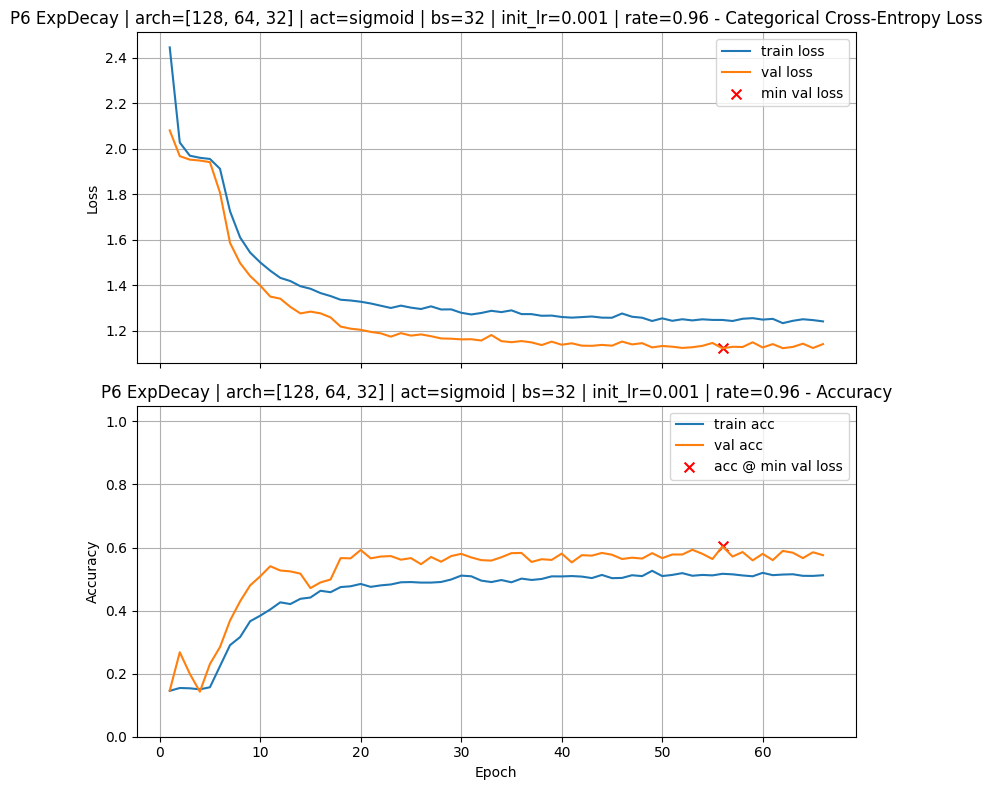

Final Training Loss:            1.2414
Final Training Accuracy:        0.5121
Final Validation Loss:          1.1415
Final Validation Accuracy:      0.5757
Minimum Validation Loss:        1.1227 (Epoch 56)
Validation Accuracy @ Min Loss: 0.6036

Test Loss: 1.1420
Test Accuracy: 0.5793

Val acc at min val_loss: 0.6036 (epoch 56)
Validation-Test Gap (accuracy): 0.024286

P6 ExpDecay | arch=[128, 64, 32] | act=sigmoid | bs=32 | init_lr=0.0005 | rate=0.92



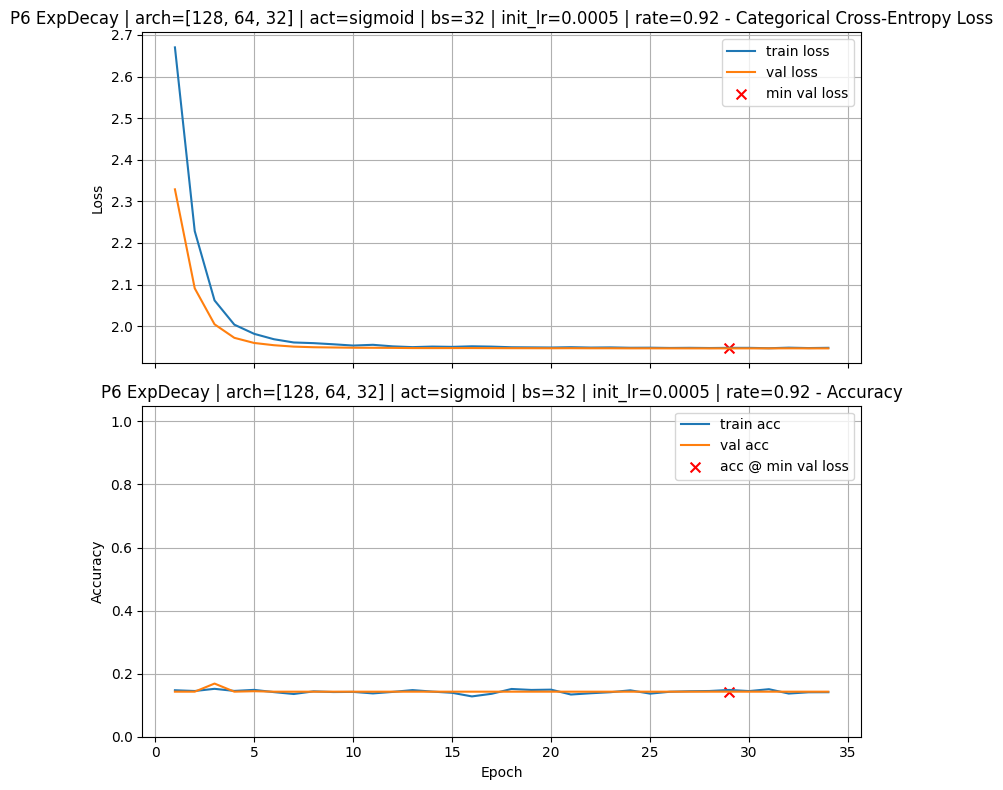

Final Training Loss:            1.9480
Final Training Accuracy:        0.1412
Final Validation Loss:          1.9467
Final Validation Accuracy:      0.1429
Minimum Validation Loss:        1.9467 (Epoch 29)
Validation Accuracy @ Min Loss: 0.1429

Test Loss: 1.9467
Test Accuracy: 0.1429

Val acc at min val_loss: 0.1429 (epoch 29)
Validation-Test Gap (accuracy): 0.000000

P6 ExpDecay | arch=[128, 64, 32] | act=sigmoid | bs=32 | init_lr=0.0005 | rate=0.96



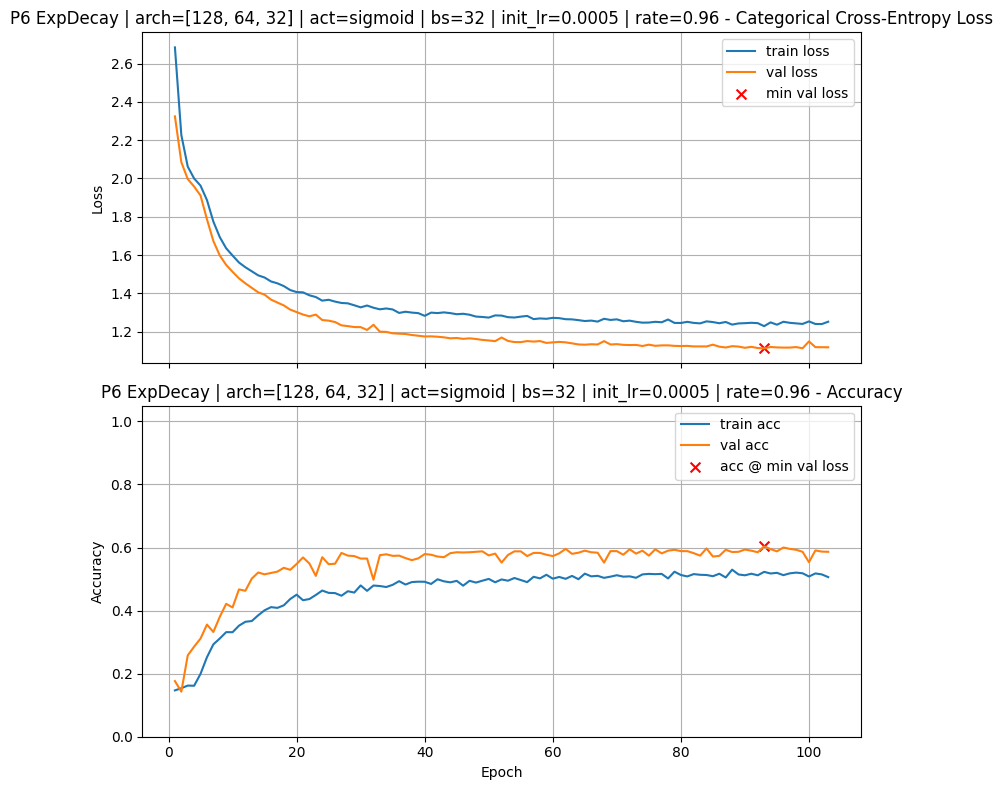

Final Training Loss:            1.2518
Final Training Accuracy:        0.5062
Final Validation Loss:          1.1182
Final Validation Accuracy:      0.5864
Minimum Validation Loss:        1.1125 (Epoch 93)
Validation Accuracy @ Min Loss: 0.6036

Test Loss: 1.1261
Test Accuracy: 0.5864

Val acc at min val_loss: 0.6036 (epoch 93)
Validation-Test Gap (accuracy): 0.017143


In [51]:

results_p6 = []

for bs in batch_sizes:
    steps_per_epoch = int(np.ceil(len(X_train) / bs))
    total_steps = max_epochs * steps_per_epoch

    # helper to set decay steps
    this_exp_steps = exp_decay_steps if exp_decay_steps is not None else total_steps

    # A) Constant LR candidates
    for lr in constant_lrs:
        model = build_custom_model(n_inputs, widths, best_activation, l2s, dropouts, n_classes)
        title = f"P6 ConstLR | arch={widths} | act={best_activation} | bs={bs} | lr={lr}"
        hist, best, (tl, ta) = train_and_test_sched(
            model, epochs=max_epochs, lr_schedule=lr, batch_size=bs,
            title=title, patience=patience, min_delta=min_delta, verbose=0
        )
        results_p6.append(("const", bs, lr, None, None, best["val_acc"], best["val_loss"], best["best_epoch"], ta))

    # B) Exponential Decay candidates
    if use_exp_decay:
        for init_lr in exp_initial_lrs:
            for decay_rate in exp_decay_rates:
                sched = tf.keras.optimizers.schedules.ExponentialDecay(
                    initial_learning_rate=init_lr,
                    decay_steps=this_exp_steps,
                    decay_rate=decay_rate,
                    staircase=False
                )
                model = build_custom_model(n_inputs, widths, best_activation, l2s, dropouts, n_classes)
                title = f"P6 ExpDecay | arch={widths} | act={best_activation} | bs={bs} | init_lr={init_lr} | rate={decay_rate}"
                hist, best, (tl, ta) = train_and_test_sched(
                    model, epochs=max_epochs, lr_schedule=sched, batch_size=bs,
                    title=title, patience=patience, min_delta=min_delta, verbose=0
                )
                results_p6.append(("exp", bs, init_lr, decay_rate, this_exp_steps, best["val_acc"], best["val_loss"], best["best_epoch"], ta))

In [52]:
best_row = max(results_p6, key=lambda r: r[5])

print("\n====================")
print("BEST Problem 6 setting:")
print(f"  lr_type     : {best_row[0]}")
print(f"  batch_size  : {best_row[1]}")
print(f"  lr/init_lr  : {best_row[2]}")
print(f"  decay_rate  : {best_row[3]}")
print(f"  decay_steps : {best_row[4]}")
print(f"  val_acc     : {best_row[5]:.4f}")
print(f"  val_loss    : {best_row[6]:.4f}")
print(f"  best_epoch  : {best_row[7]}")
print(f"  test_acc    : {best_row[8]:.4f}")


BEST Problem 6 setting:
  lr_type     : exp
  batch_size  : 32
  lr/init_lr  : 0.001
  decay_rate  : 0.96
  decay_steps : 66000
  val_acc     : 0.6036
  val_loss    : 1.1227
  best_epoch  : 56
  test_acc    : 0.5793


In [53]:
# Set a6 to the validation accuracy found by this best model

a6 = 0.6036             # Replace 0.0 with your answer

In [54]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a6 = {a6:.4f}') 

a6 = 0.6036


### Optional: Print out your results of all experiments

In [55]:
print_results()

KeyError: 0

## Reflection Questions (ungraded)

It would be a great idea to think through your answers to these questions, then give ChatGPT (or other AI tool) a PDF of your
homework, and **discuss** (not just ask) these. 

1. Activation Functions:

    - Why do you think one activation function worked better than the others for this task?
    
    - How might this choice differ for deeper or wider networks?

2. Learning Rate:

    - Would a much smaller learning rate (with many more epochs) likely produce better accuracy?
    
    - When is it worth training longer with a smaller step size, and when is it unnecessary?

3. Dropout vs. L2:

    - Which form of regularization — dropout or L2 — gave better results in your experiments?
    
    - Why might one method be more effective in this setting?

4. Combining Dropout and L2:

    - Why might the combination of dropout and L2 sometimes perform worse than using one method alone?
    
    - What does this tell you about the balance between bias and variance in regularization?

5. Best Model:

    - When you designed your best model, what trade-offs did you notice between model complexity, training stability, and generalization?
    
    - Did learning rate scheduling (if you tried it) improve results? Why might it help?